# Information Retrieval and Summarization on Multiple Users Meeting


In [4]:
import random
from datasets import load_dataset, Audio
from huggingface_hub import constants
import torchaudio
import torch
import torch.nn.functional as F
import os, json, io
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.linalg import eigh
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
from nemo.collections.asr.models import EncDecSpeakerLabelModel
from tqdm import tqdm
from transformers.models.wavlm import WavLMModel
from whisper.model import Whisper
import whisper
import warnings
warnings.filterwarnings("ignore", module="whisper.timing")
import umap
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

import soundfile as sf
from silero_vad import (
    load_silero_vad,
    read_audio,
    get_speech_timestamps,
    save_audio,
    VADIterator,
    collect_chunks,
)
from typing import Tuple, List, Dict
from speechbrain.utils.fetching import LocalStrategy
from speechbrain.inference import EncoderClassifier
import numpy as np
from rsmm_utils import (
    # dump_dataset_paths,
    # load_audio,
    # is_titanet,
    ensure_mono,
    pad_or_trim,
    segments_to_frames,
    expand_segments_to_frames,
    group_runs,
    extract_frame_errors,
    normalize_labels,
)
from embd_speech_seg import (
    extract_embeddings_from_segments,
    extract_wavlm_embeddings_from_segments,
)
import dotenv
import groq
from groq import Groq
import json

[NeMo W 2025-11-16 02:14:56 nemo_logging:361] d:\Miniconda3\envs\rsmm\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
      warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)
    


In [6]:
DATASET_DIR = "audio_out"

In [7]:
def eval_detection(detected, ground_truth, tolerance=0.01):
    """
    Evaluate speech activity detection (VAD) similar to DER
    but only for speech/silence (no speaker labels).

    Parameters
    ----------
    detected : list of (start, end) in seconds
        Predicted speech segments.
    ground_truth : list of (start, end) in seconds
        Reference speech segments.
    tolerance : float, optional
        Extra margin (in seconds) to allow small misalignments.

    Returns
    -------
    recall : float
        Proportion of ground-truth speech time correctly detected.
    fa_rate : float
        Proportion of detected speech time that is false alarm (not in GT).
    """

    # Flatten into frame-level timeline with step resolution
    # (here 10ms frames, similar to pyannote)
    frame_hop = 0.01
    if not ground_truth or not detected:
        return 0.0, 0.0

    # Find total duration
    max_time = max(
        max(e for _, e in ground_truth),
        max(e for _, e in detected)
    )

    n_frames = int(max_time / frame_hop) + 1
    gt_activity = [0] * n_frames
    det_activity = [0] * n_frames

    # Mark GT frames
    for s, e in ground_truth:
        s_i = int((s - tolerance) / frame_hop)
        e_i = int((e + tolerance) / frame_hop)
        for i in range(max(0, s_i), min(n_frames, e_i)):
            gt_activity[i] = 1

    # Mark detected frames
    for s, e in detected:
        s_i = int((s - tolerance) / frame_hop)
        e_i = int((e + tolerance) / frame_hop)
        for i in range(max(0, s_i), min(n_frames, e_i)):
            det_activity[i] = 1

    # Compute overlaps
    tp = sum(1 for g, d in zip(gt_activity, det_activity) if g == 1 and d == 1)
    fn = sum(1 for g, d in zip(gt_activity, det_activity) if g == 1 and d == 0)
    fp = sum(1 for g, d in zip(gt_activity, det_activity) if g == 0 and d == 1)

    print("True Pos, False Neg, False Pos", tp, fn, fp)
    recall = tp / (tp + fn + 1e-9)
    fa_rate = fp / (tp + fp + 1e-9)

    return recall, fa_rate


### Clustering

In [8]:
def spectral_cluster_eigengap(embeddings, min_clusters=2, max_clusters=20):
    """
    Spectral clustering with cluster count determined by the eigen-gap heuristic.
    
    Parameters
    ----------
    embeddings : array-like, shape (n_samples, n_features)
        Speaker embeddings.
    min_clusters : int, default=2
        Minimum number of clusters to consider.
    max_clusters : int, default=20
        Maximum number of clusters to consider.
    
    Returns
    -------
    labels : ndarray, shape (n_samples,)
        Cluster labels assigned to each embedding.
    k_opt : int
        Estimated optimal number of clusters (from eigen-gap).
    eigvals : ndarray
        Sorted eigenvalues of the Laplacian.
    gaps : ndarray
        Differences between consecutive eigenvalues.
    """

    # Step 1: similarity (cosine)
    sim = cosine_similarity(embeddings)
    
    # Step 2: degree matrix
    degrees = sim.sum(axis=1)
    D = np.diag(degrees)
    
    # Step 3: normalized Laplacian
    with np.errstate(divide='ignore'):
        D_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(degrees, 1e-12)))
    L = np.eye(len(sim)) - D_inv_sqrt @ sim @ D_inv_sqrt

    # Step 4: eigen decomposition
    eigvals, _ = eigh(L)
    eigvals = np.sort(eigvals)[:max_clusters+1]

    # Step 5: eigen-gap
    gaps = np.diff(eigvals)
    search_region = gaps[min_clusters-1:max_clusters-1]
    best_idx = np.argmax(search_region)
    k_opt = best_idx + min_clusters

    # Step 6: spectral clustering with k_opt
    clustering = SpectralClustering(
        n_clusters=k_opt,
        affinity="nearest_neighbors",
        assign_labels="kmeans",
        random_state=0
    ).fit(embeddings)

    return clustering.labels_, k_opt, eigvals, gaps



def agglomerative_k_search(
    embeddings: np.ndarray,
    metric: str = "cosine",
    linkage_method: str = "average",
    min_clusters: int = 2,
    max_clusters: int = 20,
):
    """
    Cluster embeddings with Agglomerative (dendrogram once, cut by k).
    Picks best k in [min_clusters, max_clusters] using silhouette score.

    Returns:
        best_labels: np.ndarray of shape (N,)
        best_k: int, chosen number of clusters
        best_score: float
        Z: linkage matrix
    """
    n_samples = embeddings.shape[0]
    if n_samples < 2:
        return np.zeros(n_samples, dtype=int), 1, 0.0, None

    # Step 1: compute pairwise distances and dendrogram (once)
    condensed = pdist(embeddings, metric=metric)
    Z = linkage(condensed, method=linkage_method)

    # Step 2: cache full distance matrix for silhouette
    dist_mat = squareform(condensed)

    best_score = -np.inf
    best_labels, best_k = None, None

    # Step 3: sweep possible k values
    for k in range(min_clusters, min(max_clusters, n_samples - 1) + 1):
        labels = fcluster(Z, t=k, criterion="maxclust")
        n_clusters = len(set(labels))
        if n_clusters < 2:
            continue

        try:
            score = silhouette_score(dist_mat, labels, metric="precomputed")
        except Exception:
            score = -davies_bouldin_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_labels = labels
            best_k = n_clusters

    # Fallback: if nothing valid, just cut at min_clusters
    if best_labels is None:
        best_labels = fcluster(Z, t=min_clusters, criterion="maxclust")
        best_k = min_clusters
        try:
            best_score = silhouette_score(dist_mat, best_labels, metric="precomputed")
        except Exception:
            best_score = -davies_bouldin_score(embeddings, best_labels)

    return best_labels, best_k, best_score


In [9]:
def umap_cluster_embeddings(
    embeddings,
    reducer_dim=10,
    gt_labels=None,
    n_clusters=None,
    random_state=42,
):
    """
    UMAP -> KMeans clustering.

    Returns:
      speaker_labels (list[str])   - e.g. ["SPEAKER_00", ...] (compatible with your pipeline)
      cluster_ids (ndarray[int])   - raw numeric cluster ids from KMeans
      emb_reduced (ndarray)        - UMAP-reduced embeddings (n x reducer_dim)
      label2id (dict)              - map from string label -> numeric id (for plotting)
      results (dict)               - metrics and extra info
    """
    # 1) UMAP reduction
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=reducer_dim,
        metric="cosine",
        random_state=random_state,
    )
    emb_reduced = reducer.fit_transform(embeddings)

    print(len(set(gt_labels)))
    # 2) cluster count
    if n_clusters is None:
        if gt_labels is not None:
            n_clusters = len(set(gt_labels))
        else:
            raise ValueError("Need n_clusters or gt_labels to infer cluster count")

    # 3) clustering
    km = KMeans(n_clusters=n_clusters, random_state=random_state)
    cluster_ids = km.fit_predict(emb_reduced)   # numeric 0..K-1 (but order not guaranteed)

    # 4) build stable id->label using order-of-appearance of cluster ids
    unique_clusters = list(dict.fromkeys(cluster_ids))  # preserve appearance order
    id2label = {cid: f"SPEAKER_{i:02d}" for i, cid in enumerate(unique_clusters)}
    speaker_labels = [id2label[cid] for cid in cluster_ids]

    # 5) label -> numeric id mapping (for plotting)
    unique_labels = [id2label[cid] for cid in unique_clusters]
    label2id = {label: i for i, label in enumerate(unique_labels)}
    numeric_labels = np.array([label2id[lbl] for lbl in speaker_labels], dtype=int)

    # 6) metrics (use numeric cluster_ids for ARI/NMI)
    results = {
        "umap_embeddings": emb_reduced,
        "cluster_ids": cluster_ids,
        "label2id": label2id,
        "numeric_labels": numeric_labels,
        "ari": None,
        "nmi": None,
    }
    if gt_labels is not None and len(gt_labels) == len(cluster_ids):
        results["ari"] = adjusted_rand_score(gt_labels, cluster_ids)
        results["nmi"] = normalized_mutual_info_score(gt_labels, cluster_ids)

    return speaker_labels, cluster_ids, emb_reduced, label2id, results


In [10]:
def transcribe_chunks(waveform, sr, chunks, asr_model: Whisper):
    """
    Run Whisper ASR on pre-chunked waveform segments.
    - waveform: torch.Tensor [1, num_samples]
    - sr: sample rate
    - chunks: list of dicts with {start, end, segments} in samples
    - asr_model: loaded Whisper model
    Returns transcripts aligned in **samples** (not seconds).
    """
    transcripts = []

    for i, c in tqdm(enumerate(chunks), total=len(chunks), desc="Transcribing"):
    # Slice chunk by samples
        segment = waveform[:, c["start"]:c["end"]].cpu().numpy()
        segment = segment.squeeze().astype("float32")

        # Normalize if needed
        # if segment.max() > 1.0:
        #     segment = segment / max(1e-9, abs(segment).max())

        # Run Whisper with timestamps
        result = asr_model.transcribe(
            segment,
            fp16=False,  # safer on CPU/small GPU
            word_timestamps=True,  # return per-word timestamps
            beam_size=3,  # beam search for stability
            temperature=(0, 0.1, 0.2, 0.4, 0.8),  # deterministic output
            compression_ratio_threshold=1.8,
        )

        # Convert Whisper word timestamps (sec) → samples
        words = []
        for w in result.get("segments", []):
            for item in w["words"]:
                words.append(
                    {
                        "word": item["word"],
                        "start": c["start"] + int(item["start"] * sr),
                        "end": c["start"] + int(item["end"] * sr),
                    }
                )

        transcripts.append(
            {
                "chunk_id": i,
                "start": c["start"],  # in samples
                "end": c["end"],  # in samples
                "text": result["text"].strip(),
                "words": words,
            }
        )

        # Optional debug log in seconds
        # print(f"[Chunk {i}] {c['start']/sr:.2f}-{c['end']/sr:.2f}s: {result['text'].strip()}")
        # print(f"[Chunk {i}] {c['start']/sr:.4f}-{c['end']/sr:.4f}s", end=" ")

    return transcripts


def chunk_by_silence_and_overlap(
    speech_timestamps,
    sr,
    min_silence=2.0,
    max_chunk=60.0,
    overlap=2.0,
):
    """
    Create ASR chunks from diarization speech timestamps.
    Works in samples, not seconds.
    Ensures that overlapping windows only carry their relevant segments.
    """
    min_silence_samples = int(min_silence * sr)
    max_chunk_samples = int(max_chunk * sr)
    overlap_samples = int(overlap * sr)

    chunks = []
    cur_segments = []
    cur_start, cur_end = None, None

    # --- First pass: group by silence gaps ---
    for seg in speech_timestamps:
        start, end = (seg["start"], seg["end"]) if isinstance(seg, dict) else seg

        if cur_start is None:
            cur_start, cur_end = start, end
            cur_segments = [(start, end)]
            continue

        gap = start - cur_end

        if gap >= min_silence_samples:
            chunks.append(
                {"start": cur_start, "end": cur_end, "segments": cur_segments}
            )
            cur_start, cur_end = start, end
            cur_segments = [(start, end)]
        else:
            cur_end = end
            cur_segments.append((start, end))

    if cur_segments:
        chunks.append({"start": cur_start, "end": cur_end, "segments": cur_segments})

    # --- Second pass: split long chunks with overlap ---
    final_chunks = []
    for c in chunks:
        duration = c["end"] - c["start"]
        if duration <= max_chunk_samples:
            final_chunks.append(c)
        else:
            start = c["start"]
            while start < c["end"]:
                end = min(start + max_chunk_samples, c["end"])

                # ✅ keep only segments that intersect this sub-window
                sub_segments = [
                    (s, e)
                    for (s, e) in c["segments"]
                    if e > start and s < end
                ]

                final_chunks.append(
                    {"start": start, "end": end, "segments": sub_segments}
                )

                if end == c["end"]:
                    break
                start = end - overlap_samples  # slide with overlap

    return final_chunks


def assign_speakers(transcripts, diar_segments, sr, snap_gap_sec=1):
    snap_gap_samples = int(snap_gap_sec * sr)
    results = []
    cur_speaker, cur_words = None, []

    # flatten word-level info across chunks
    words_all = []
    for t in transcripts:
        words_all.extend(t["words"])

    for w in words_all:
        w_mid = (w["start"] + w["end"]) // 2

        # find diar segment covering this word
        candidates = [
            seg for seg in diar_segments if seg["start"] <= w_mid <= seg["end"]
        ]
        if candidates:
            speaker = candidates[0]["speaker"]
        else:
            # nearest diar segment
            nearest = min(
                diar_segments,
                key=lambda s: min(abs(w_mid - s["start"]), abs(w_mid - s["end"])),
            )
            gap = min(abs(w_mid - nearest["start"]), abs(w_mid - nearest["end"]))
            speaker = nearest["speaker"] if gap <= snap_gap_samples else None

        # group by speaker
        if speaker != cur_speaker:
            if cur_words:
                results.append(
                    {
                        "speaker": (
                            f"Speaker {cur_speaker}"
                            if isinstance(cur_speaker, (int, np.integer))
                            else (cur_speaker or "Unknown")
                        ),
                        "start": min(wd["start"] for wd in cur_words),
                        "end": max(wd["end"] for wd in cur_words),
                        "text": " ".join(wd["word"] for wd in cur_words),
                    }
                )
            cur_speaker, cur_words = speaker, [w]
        else:
            cur_words.append(w)

    # flush last
    if cur_words:
        results.append(
            {
                "speaker": (
                    f"Speaker {cur_speaker}"
                    if isinstance(cur_speaker, (int, np.integer))
                    else (cur_speaker or "Unknown")
                ),
                "start": min(wd["start"] for wd in cur_words),
                "end": max(wd["end"] for wd in cur_words),
                "text": " ".join(wd["word"] for wd in cur_words),
            }
        )

    return results


### Diarization

In [11]:
def run_vad_segmentation(waveform, vad_model, sample_rate):
    return get_speech_timestamps(
        waveform,
        vad_model,
        sampling_rate=sample_rate,
        threshold=0.1,
        max_speech_duration_s=5.0,
        min_speech_duration_ms=50,
        min_silence_duration_ms=50,
    )


In [12]:
def split_segments_by_length(speech_segments, sample_rate, min_len_sec=0.6):
    min_len = int(min_len_sec * sample_rate)
    valid, skipped = [], []
    for ts in speech_segments:
        if ts["end"] - ts["start"] < min_len:
            skipped.append(ts)
        else:
            valid.append(ts)
    return valid, skipped

In [13]:
def extract_large_embeddings(waveform, encoder, segments, seg_len_sec=2.0):
    return (
        extract_embeddings_from_segments(
            waveform,
            encoder,
            segments,
            n_samples=3,
            seg_len_sec=seg_len_sec,
            skip_short=False,
        )
        .squeeze(1)
        .numpy()
    )


In [14]:
def normalize_if_needed(x, use_cosine_norm):
    if not use_cosine_norm:
        return x
    n = np.linalg.norm(x, axis=1, keepdims=True) + 1e-9
    return x / n


In [15]:
def cluster_large_segments(valid_segments, embeddings_norm):
    speaker_labels, _, _, _ = spectral_cluster_eigengap(embeddings_norm)
    labeled = [
        {"speaker": f"Speaker {lbl}", "start": seg["start"], "end": seg["end"]}
        for seg, lbl in zip(valid_segments, speaker_labels)
    ]
    return speaker_labels, len(set(speaker_labels)), labeled


In [16]:
def assign_segments_to_clusters(embeddings, centers, metric="cosine"):
    if metric == "cosine":
        norms_emb = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
        norms_ctr = np.linalg.norm(centers, axis=1, keepdims=True) + 1e-9
        sim = (embeddings @ centers.T) / (norms_emb * norms_ctr.T)
        labels = np.argmax(sim, axis=1)
        conf = np.max(sim, axis=1)
    else:
        # Placeholder: you can plug Mahalanobis, PLDA, or density-based logic here
        dists = np.linalg.norm(embeddings[:, None, :] - centers[None, :, :], axis=-1)
        labels = np.argmin(dists, axis=1)
        conf = 1 / (1 + np.min(dists, axis=1))
    return labels, conf


In [17]:
def dbg_print(msg):
    print("[DBG]", msg)

In [18]:
def check_parent_splitting(valid_large_segments, phase2_result, merged_segments):
    # For each parent, if any sub in phase2_result["outliers"] falls inside parent,
    # check merged_segments contains splits (parent is not present intact covering outlier)
    outliers = phase2_result.get("outliers", [])
    intact_parents = []
    for parent in valid_large_segments:
        p_s, p_e = parent["start"], parent["end"]
        parent_present = any(m["start"] <= p_s + 1e-6 and m["end"] >= p_e - 1e-6 for m in merged_segments)
        # if there are outliers inside parent
        outs_in_parent = [o for o in outliers if o["start"] >= p_s and o["end"] <= p_e]
        if outs_in_parent and parent_present:
            intact_parents.append(parent)
    dbg_print(f"Parents containing outliers but still present intact in merged_segments: {len(intact_parents)}")
    if intact_parents:
        dbg_print("Example intact parents: " + str(intact_parents[:3]))


In [19]:
def refine_clusters_with_wavlm(
    waveform,
    encoder_small,
    valid_segments,
    skipped_segments,
    speaker_labels,
    n_speakers,
    use_cosine_norm,
    seg_len_small=0.3,
    stride_small=0.1,
):
    """
    Phase 2 — Intra-cluster refinement using WavLM.
    Unified output keys for consistent downstream use.
    """
    sample_rate = 16000
    seg_samples = int(seg_len_small * sample_rate)
    stride_samples = int(stride_small * sample_rate)

    # Edge case: no valid segments
    if not valid_segments:
        return {
            "refined_clusters": {},
            "segments_refined": [],
            "outliers": [],
            "outlier_embeddings": np.empty((0, 0)),
            "skipped_embeddings": np.empty((0, 0)),
            "skipped_segments": [],
            "all_embeddings": np.empty((0, 0)),
            "all_labels": [],
        }

    # ------------------------------
    # Step 1 — build subsegments
    # ------------------------------
    all_subsegments, all_labels = [], []
    for seg, lbl in zip(valid_segments, speaker_labels):
        start, end = seg["start"], seg["end"]
        seg_dur = end - start
        if seg_dur < seg_samples:
            continue

        # stride = min(int(seg_samples * 0.5), stride_samples)
        max_subs = 20
        positions = list(range(start, end - seg_samples + 1, stride_samples))
        if len(positions) > max_subs:
            step = max(1, len(positions) // max_subs)
            positions = positions[::step]

        for s in positions:
            all_subsegments.append({"start": s, "end": s + seg_samples})
            all_labels.append(lbl)

    if not all_subsegments:
        return {
            "refined_clusters": {},
            "segments_refined": [],
            "outliers": [],
            "outlier_embeddings": np.empty((0, 0)),
            "skipped_embeddings": np.empty((0, 0)),
            "skipped_segments": skipped_segments,
            "all_embeddings": np.empty((0, 0)),
            "all_labels": [],
        }

    # ------------------------------
    # Step 2 — embed
    # ------------------------------
    all_embs = (
        extract_wavlm_embeddings_from_segments(
            waveform, encoder_small, all_subsegments,
            seg_len_sec=seg_len_small, n_samples=1, skip_short=False
        ).squeeze(1).numpy()
    )
    emb_dim = all_embs.shape[1]
    all_embs = normalize_if_needed(all_embs, True)
    cluster_subembs = {i: [] for i in range(n_speakers)}
    cluster_segments = {i: [] for i in range(n_speakers)}
    for emb, seg, lbl in zip(all_embs, all_subsegments, all_labels):
        cluster_subembs[lbl].append(emb)
        cluster_segments[lbl].append(seg)
    for lbl in range(n_speakers):
        cluster_subembs[lbl] = (
            np.stack(cluster_subembs[lbl]) if cluster_subembs[lbl] else np.empty((0, emb_dim))
        )
    # Global spectral clustering on all subsegment embeddings and comparison with original labels
    # --- Global clustering ---
    all_embs_norm_global = normalize_if_needed(all_embs, use_cosine_norm)

    # run spectral clustering (same helper as before)
    global_labels, _, _, _ = spectral_cluster_eigengap(all_embs_norm_global)
    global_labels = np.asarray(global_labels)

    # map original string labels to ints (preserve first-seen order)
    unique_true = list(dict.fromkeys(all_labels))
    true_map = {lab: i for i, lab in enumerate(unique_true)}
    true_ids = np.array([true_map[l] for l in all_labels], dtype=int)

    # --- Build contingency matrix (pred_clusters x true_labels) ---
    pred_cluster_ids = np.unique(global_labels)
    n_pred = pred_cluster_ids.max() + 1
    n_true = len(unique_true)
    cont = np.zeros((n_pred, n_true), dtype=int)

    for p, t in zip(global_labels, true_ids):
        cont[int(p), int(t)] += 1

    # --- Best one-to-one assignment (Hungarian algorithm) ---
    m = max(n_pred, n_true)
    cost = np.zeros((m, m), dtype=int)
    cost[:n_pred, :n_true] = -cont  # negative because linear_sum_assignment minimizes
    row_ind, col_ind = linear_sum_assignment(cost)

    # --- Evaluate accuracy + mapping ---
    matched = 0
    label_map = {}
    for r, c in zip(row_ind, col_ind):
        if r < n_pred and c < n_true:
            matched += cont[r, c]
            label_map[r] = c  # map predicted cluster r → true label c

    accuracy = matched / len(all_labels)

    # --- Optional: remap predicted labels to true label indices ---
    mapped_labels = np.array([label_map.get(lbl, lbl) for lbl in global_labels])
    # you can then use mapped_labels instead of raw global_labels for evaluation or saving

    # --- Summary for inspection ---
    global_clustering_comparison = {
        "n_pred_clusters": int(n_pred),
        "n_true_labels": int(n_true),
        "true_label_names": unique_true,
        "contingency": cont,
        "label_map": label_map,  # predicted cluster -> true label index
        "accuracy": float(accuracy),
    }

    print(f"Global spectral clustering: {n_pred} clusters vs {n_true} true labels, accuracy={accuracy:.4f}")
    print("Label map (pred→true):", label_map)
    # ------------------------------
    # Step 3 — refinement
    # ------------------------------
    refined_clusters = {}
    all_outliers, all_outlier_embs, refined_segments = [], [], []

    for i in range(n_speakers):
        subembs = cluster_subembs[i]
        if len(subembs) == 0:
            continue
        subembs_norm = normalize_if_needed(subembs, use_cosine_norm)
        sub_labels, _, _, _ = spectral_cluster_eigengap(subembs_norm)

        subclusters = {}
        local_outliers, local_outlier_embs = [], []

        for lbl in np.unique(sub_labels):
            sub_idx = np.where(sub_labels == lbl)[0]
            sub_embs = subembs_norm[sub_idx]
            centroid = np.mean(sub_embs, axis=0)

            dists = np.linalg.norm(sub_embs - centroid, axis=1)
            thresh = np.mean(dists) + 1.5 * np.std(dists)
            outlier_mask = dists > thresh

            outlier_idx = sub_idx[outlier_mask]
            kept_idx = sub_idx[~outlier_mask]

            outlier_embs = sub_embs[outlier_mask]
            outlier_segments = [cluster_segments[i][j] for j in outlier_idx]
            kept_segments = [cluster_segments[i][j] for j in kept_idx]

            local_outliers.extend(outlier_segments)
            if len(outlier_embs) > 0:
                local_outlier_embs.append(outlier_embs)

            # Save subcluster
            subclusters[int(lbl)] = {
                "embs": sub_embs[~outlier_mask],
                "segments": kept_segments,
                "centroid": centroid,
                "count": len(kept_segments),
            }

            # Flat refined segments
            for seg in kept_segments:
                seg = {**seg, "speaker": f"Speaker{i}"}
                refined_segments.append(seg)

        if local_outlier_embs:
            local_outlier_embs = np.concatenate(local_outlier_embs, axis=0)
            all_outlier_embs.append(local_outlier_embs)

        refined_clusters[i] = {
            "subembs": subembs_norm,
            "sublabels": sub_labels,
            "subclusters": subclusters,
            "outliers": local_outliers,
        }

        all_outliers.extend(local_outliers)

    if all_outlier_embs:
        all_outlier_embs = np.concatenate(all_outlier_embs, axis=0)
    else:
        all_outlier_embs = np.empty((0, emb_dim))

    # ------------------------------
    # Step 4 — skipped segments
    # ------------------------------
    if skipped_segments:
        skipped_embs = (
            extract_wavlm_embeddings_from_segments(
                waveform, encoder_small, skipped_segments,
                seg_len_sec=seg_len_small, n_samples=1, skip_short=False
            ).squeeze(1).numpy()
        )
    else:
        skipped_embs = np.empty((0, emb_dim))
    skipped_embs_norm = normalize_if_needed(skipped_embs, True)
    assert all_embs.shape[1] == skipped_embs.shape[1], (
        f"outliers={all_embs.shape[1]}, skipped={skipped_embs.shape[1]}"
    )
    return {
        "refined_clusters": refined_clusters,
        "refined_segments": refined_segments,
        "outliers": all_outliers,
        "outlier_embeddings": all_outlier_embs,
        "skipped_embeddings": skipped_embs_norm,
        "skipped_segments": skipped_segments,
        "all_embeddings": all_embs,
        "all_labels": all_labels,
    }


In [20]:
def relabel_outliers_and_skipped(
    refined_clusters,
    outlier_embeddings=None,
    outlier_segments=None,
    skipped_embeddings=None,
    skipped_segments=None,
    assign_threshold=0.35,
    use_cosine_norm=False,
):
    """
    Phase 3: assign outlier + skipped candidates to refined subcluster centroids.

    Inputs:
      - refined_clusters: dict from Phase2. Each value has "subclusters": {subid: {"centroid","embs","segments",...}, ...}
      - outlier_embeddings: np.ndarray (N_out, D) or None
      - outlier_segments: list of segment dicts (N_out) or None
      - skipped_embeddings: np.ndarray (N_skip, D) or None
      - skipped_segments: list of segment dicts (N_skip) or None

    Behavior:
      - Merge outliers + skipped into one candidate list (outliers first).
      - Use subcluster centroids as targets.
      - Compute cosine similarity and assign each candidate to nearest centroid.
      - If sim >= assign_threshold => "high" confidence, else "tentative" (still assigned to nearest).
      - Always returns labels for every candidate (zero miss-rate).
    Returns:
      {
        "segments_reassigned": [ {segment_dict + speaker, confidence, tentative, assigned_to}, ... ],
        "assignments": [speaker_label_str, ...],
        "n_speakers_total": total_count (coarse clusters count),
        "centroid_keys": centroid_key_list  # optional, useful for debugging
      }
    """

    # Normalize inputs / defaults
    outlier_embeddings = np.asarray(outlier_embeddings) if outlier_embeddings is not None else np.empty((0, 0))
    skipped_embeddings = np.asarray(skipped_embeddings) if skipped_embeddings is not None else np.empty((0, 0))
    outlier_segments = list(outlier_segments) if outlier_segments is not None else []
    skipped_segments = list(skipped_segments) if skipped_segments is not None else []

    # Build candidate embeddings and segments in stable order
    cand_embs_list = []
    cand_segs = []

    if outlier_embeddings.size != 0:
        cand_embs_list.append(outlier_embeddings)
        cand_segs.extend(outlier_segments)
    if skipped_embeddings.size != 0:
        cand_embs_list.append(skipped_embeddings)
        cand_segs.extend(skipped_segments)

    if len(cand_segs) == 0:
        return {
            "segments_reassigned": [],
            "assignments": [],
            "n_speakers_total": len(refined_clusters),
            "centroid_keys": [],
        }

    # stack embeddings (handle case where either array is empty)
    cand_embs = np.vstack(cand_embs_list) if len(cand_embs_list) > 0 else np.empty((0,))

    # Build list of centroids and keys (coarse_id, subid)
    centroids = []
    centroid_keys = []
    for coarse_id, info in refined_clusters.items():
        subcls = info.get("subclusters", {})
        for subid, sinfo in subcls.items():
            cent = sinfo.get("centroid", None)
            if cent is None:
                embs = np.asarray(sinfo.get("embs", []))
                if embs.size == 0:
                    continue
                cent = np.mean(embs, axis=0)
            centroids.append(np.asarray(cent))
            centroid_keys.append((coarse_id, subid))

    if len(centroids) == 0:
        # No centroids: mark all as new tentative speakers
        labeled = []
        next_new_id = max(refined_clusters.keys(), default=-1) + 1
        for seg in cand_segs:
            lbl = f"Speaker{next_new_id}"
            labeled.append({**seg, "speaker": lbl, "confidence": 0.0, "tentative": True, "assigned_to": None})
            next_new_id += 1
        return {
            "segments_reassigned": labeled,
            "assignments": [s["speaker"] for s in labeled],
            "n_speakers_total": next_new_id,
            "centroid_keys": [],
        }

    centroids = np.stack(centroids)  # (M, D)

    # Normalize if using cosine
    if use_cosine_norm:
        # normalize centroids and candidates safely
        cent_norms = np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-9
        centroids_normed = centroids / cent_norms
        cand_norms = np.linalg.norm(cand_embs, axis=1, keepdims=True) + 1e-9
        cand_embs_normed = cand_embs / cand_norms
    else:
        centroids_normed = centroids
        cand_embs_normed = cand_embs

    # cosine similarity matrix (N_candidates x M_centroids)
    sims = cand_embs_normed.dot(centroids_normed.T)

    best_idx = np.argmax(sims, axis=1)
    best_val = np.max(sims, axis=1).astype(float)

    # Assign to nearest centroid, mark tentative if below threshold
    labeled_segments = []
    assignments = []
    for i, seg in enumerate(cand_segs):
        sim = float(best_val[i])
        centroid_index = int(best_idx[i])
        coarse_id, subid = centroid_keys[centroid_index]

        if sim >= assign_threshold:
            label = f"Speaker{coarse_id}"
            tentative = False
        else:
            # still assign nearest, but mark tentative to allow later re-eval
            label = f"Speaker{coarse_id}"
            tentative = True

        assigned_info = {
            **seg,
            "speaker": label,
            "confidence": sim,
            "tentative": tentative,
            "assigned_to": {"coarse": coarse_id, "sub": subid},
        }
        labeled_segments.append(assigned_info)
        assignments.append(label)

    n_total = len(cand_segs)
    n_tent = sum(1 for s in labeled_segments if s["tentative"])
    avg_conf = np.mean(best_val) if len(best_val) else 0
    min_conf = np.min(best_val) if len(best_val) else 0
    max_conf = np.max(best_val) if len(best_val) else 0

    print(f"[DBG] Reassignment: total={n_total}, tentative={n_tent}, "
          f"avg_conf={avg_conf:.3f}, min={min_conf:.3f}, max={max_conf:.3f}")
    print("[DBG] Similarity distribution:", np.histogram(best_val, bins=np.linspace(0,1,11))[0])

    n_speakers_total = max(refined_clusters.keys(), default=-1) + 1

    return {
        "segments_reassigned": labeled_segments,
        "assignments": assignments,
        "n_speakers_total": n_speakers_total,
        "centroid_keys": centroid_keys,
    }


In [21]:
def merge_segments_consistently(
    labeled_large_segments,
    refined_segments,
    relabeled_segments,
    tolerance=0.05,  # small time tolerance in seconds
):
    """
    Combine segments from all stages into one consistent, non-overlapping list.
    Priority:
        1. relabeled_segments (outliers + skipped reassigned)
        2. refined_segments (WavLM small segments)
        3. labeled_large_segments (ECAPA base)
    """

    # Combine all with priority tagging
    all_segments = []
    for seg in labeled_large_segments:
        all_segments.append({**seg, "priority": 0})
    for seg in refined_segments:
        all_segments.append({**seg, "priority": 1})
    for seg in relabeled_segments:
        all_segments.append({**seg, "priority": 2})

    # Sort by start time, then by priority descending
    all_segments.sort(key=lambda s: (s["start"], -s["priority"]))

    merged = []
    for seg in all_segments:
        s, e = seg["start"], seg["end"]
        # Skip if fully covered by higher-priority segment
        overlapped = False
        for m in merged:
            if s >= m["start"] - tolerance and e <= m["end"] + tolerance:
                overlapped = True
                break
        if overlapped:
            continue

        # If overlaps partially, trim or split intelligently
        trimmed_start, trimmed_end = s, e
        for m in merged:
            if not (e <= m["start"] or s >= m["end"]):
                if s < m["start"] and e > m["start"]:
                    trimmed_end = min(e, m["start"])
                elif e > m["end"] and s < m["end"]:
                    trimmed_start = max(s, m["end"])
        if trimmed_end - trimmed_start > 0:
            merged.append({**seg, "start": trimmed_start, "end": trimmed_end})

    # Sort by start again to ensure order
    merged.sort(key=lambda x: x["start"])
    return merged


In [22]:
def visualize_embeddings(emb_large, emb_small, labels_large, labels_small):
    try:
        reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, metric="cosine", random_state=42)
    except Exception:
        from sklearn.decomposition import PCA
        reducer = PCA(n_components=2)

    emb_large_2d = reducer.fit_transform(emb_large)
    emb_small_2d = reducer.transform(emb_small)
    print("set size and items", len(set(labels_large)), len(set(labels_small)), set(labels_large), set(labels_small))
    norm_labels_large = normalize_labels(labels_large)
    norm_labels_small = normalize_labels(labels_small)
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    plt.scatter(emb_large_2d[:, 0], emb_large_2d[:, 1], c=norm_labels_large, cmap="tab10", s=30)
    plt.title("Phase 1 — Large embeddings (coarse clusters)")

    plt.subplot(1, 2, 2)
    plt.scatter(emb_small_2d[:, 0], emb_small_2d[:, 1], c=norm_labels_small, cmap="tab10", s=10, alpha=0.8)
    plt.title("Phase 2 — Skipped short segments (fine clustering)")
    plt.tight_layout()
    plt.show()


In [23]:
def diarization(
    waveform,
    sample_rate,
    vad_model,
    encoder_large,
    encoder_small,
    meta=None,
    use_cosine_norm: bool = False,
    plot: bool = True,
):
    """
    Two-phase diarization:
      - Phase 1: coarse clusters from large encoder (ECAPA/Titanet)
      - Phase 2: fine clusters from small encoder (WavLM), on skipped short segments
    """

    # --- Phase 1: large segments and ECAPA embeddings ---
    speech_segments = get_speech_timestamps(
        waveform,
        vad_model,
        sampling_rate=sample_rate,
        threshold=0.1,
        # neg_threshold=0.2,
        max_speech_duration_s=3.0,
        min_speech_duration_ms=100,
        min_silence_duration_ms=50,
    )

    seg_len_large = 1.2
    seg_len_small = 0.5

    # 🔸 capture which segments were skipped due to length
    valid_segments = []
    skipped_segments = []

    # seg_len = int(seg_len_large * sample_rate)
    min_len = int(0.5 * sample_rate)  # same as min_len_ratio * sample_rate

    # partition segments before extraction
    for ts in speech_segments:
        start, end = ts["start"], ts["end"]
        seg_len_actual = end - start
        if seg_len_actual < min_len:
            skipped_segments.append(ts)
        else:
            valid_segments.append(ts)

    embeddings_large = (
        extract_embeddings_from_segments(
            waveform,
            encoder_large,
            valid_segments,  # only long enough ones
            n_samples=3,
            seg_len_sec=seg_len_large,
            skip_short=False,  # we've already filtered manually
        )
        .squeeze(1)
        .numpy()
    )

    if use_cosine_norm:

        def normalize_rows(x):
            n = np.linalg.norm(x, axis=1, keepdims=True) + 1e-9
            return x / n

        embeddings_large_norm = normalize_rows(embeddings_large)
    else:
        embeddings_large_norm = embeddings_large

    # --- Phase 1 clustering ---
    speaker_labels, _, _, _ = spectral_cluster_eigengap(embeddings_large_norm, min_clusters=3, max_clusters=10)
    labeled_large_segments = [
        {"speaker": f"Speaker {lbl}", "start": seg["start"], "end": seg["end"]}
        for seg, lbl in zip(valid_segments, speaker_labels)
    ]
    n_speakers = len(set(speaker_labels))
    print("Num. of Speakers:", n_speakers)

    # --- Phase 2: fine clustering on skipped short segments ---
    # 🔸 reuse skipped_segments instead of new VAD pass
    if len(skipped_segments) == 0:
        print("No skipped short segments — skipping small phase.")
        return {
            "segments_large": labeled_large_segments,
            "segments_small": [],
            "merged_segments": labeled_large_segments,
            "labels": [seg["speaker"] for seg in labeled_large_segments],
            "pivots": None,
        }

        # --- Leak pivots: convert large-cluster representatives into WavLM-space ---
    # Initialize a dict (or list) of pivot segments per cluster
    pivot_segments_by_cluster = {i: [] for i in range(n_speakers)}

    for i in range(n_speakers):
        cluster_segments = [
            seg for seg, lbl in zip(valid_segments, speaker_labels) if lbl == i
        ]
        if cluster_segments:
            pivot_segments_by_cluster[i].extend(
                random.sample(cluster_segments, k=min(3, len(cluster_segments)))
            )

    flat_pivots = [seg for segs in pivot_segments_by_cluster.values() for seg in segs]
    pivot_wavlm_embs = (
        extract_wavlm_embeddings_from_segments(
            waveform,
            encoder_small,
            flat_pivots,
            seg_len_sec=seg_len_small,
            n_samples=1,
            skip_short=False,
        )
        .squeeze(1)
        .numpy()
    )

    pivot_embs_by_cluster = {i: [] for i in range(n_speakers)}
    offset = 0
    for i in range(n_speakers):
        n = len(pivot_segments_by_cluster[i])
        pivot_embs_by_cluster[i].extend(pivot_wavlm_embs[offset : offset + n])
        offset += n

    # --- Compute WavLM pivot centers ---
    wavlm_pivot_centers = []
    for i in range(n_speakers):
        if len(pivot_embs_by_cluster[i]) > 0:
            wavlm_pivot_centers.append(np.mean(pivot_embs_by_cluster[i], axis=0))
        else:
            wavlm_pivot_centers.append(
                np.mean(pivot_wavlm_embs, axis=0)
            )  # global mean fallback
    wavlm_pivot_centers = np.stack(wavlm_pivot_centers)

    # --- Small-segment embeddings ---
    embeddings_small = (
        extract_wavlm_embeddings_from_segments(
            waveform,
            encoder_small,
            skipped_segments,
            seg_len_sec=seg_len_small,
            n_samples=1,
            skip_short=False,
        )
        .squeeze(1)
        .numpy()
    )

    if use_cosine_norm:
        n = np.linalg.norm(embeddings_small, axis=1, keepdims=True) + 1e-9
        embeddings_small_norm = embeddings_small / n
    else:
        embeddings_small_norm = embeddings_small

    # --- Cosine distance assignment ---
    pivot_norms = np.linalg.norm(wavlm_pivot_centers, axis=1, keepdims=True) + 1e-9
    emb_norms = np.linalg.norm(embeddings_small_norm, axis=1, keepdims=True) + 1e-9
    cosine_sim = (embeddings_small_norm @ wavlm_pivot_centers.T) / (
        emb_norms * pivot_norms.T
    )

    assigned_labels = np.argmax(cosine_sim, axis=1)
    assigned_conf = np.max(cosine_sim, axis=1)

    # --- Forced assignment (no missing) ---
    final_labels = assigned_labels  # every short segment gets a label

    labeled_small_segments = [
        {**seg, "speaker": f"Speaker {lbl}"}
        for seg, lbl in zip(skipped_segments, final_labels)
    ]

    merged_segments = sorted(
        labeled_large_segments + labeled_small_segments, key=lambda x: x["start"]
    )
    # print("Assigned Confident", cosine_sim)
    # print("pivot centers", wavlm_pivot_centers, pivot_norms)
    merged_labels = [seg["speaker"] for seg in merged_segments]

    # --- Optional visualization ---
    if plot:
        try:
            reducer = umap.UMAP(
                n_neighbors=10, min_dist=0.01, metric="cosine", random_state=42
            )
        except Exception:
            from sklearn.decomposition import PCA

            reducer = PCA(n_components=2)

        emb_large_2d = reducer.fit_transform(embeddings_large_norm)
        emb_small_2d = reducer.transform(embeddings_small_norm)

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.scatter(
            emb_large_2d[:, 0], emb_large_2d[:, 1], c=speaker_labels, cmap="tab10", s=30
        )
        plt.title("Phase 1 — Large embeddings (coarse clusters)")

        plt.subplot(1, 2, 2)
        plt.scatter(
            emb_small_2d[:, 0],
            emb_small_2d[:, 1],
            c=assigned_labels,
            cmap="tab10",
            s=10,
            alpha=0.8,
        )
        plt.title("Phase 2 — Skipped short segments (fine clustering)")
        plt.tight_layout()
        plt.show()

    return {
        "segments_large": labeled_large_segments,
        "segments_small": labeled_small_segments,
        "merged_segments": merged_segments,
        "labels": merged_labels,
        "pivots": wavlm_pivot_centers,
    }

In [24]:
# def diarization(
#     waveform,
#     sample_rate,
#     vad_model,
#     encoder_large,
#     encoder_small,
#     meta=None,
#     use_cosine_norm=False,
#     plot=True,
# ):
#     """
#     Full diarization pipeline.
#       Phase 1: Coarse clustering with ECAPA.
#       Phase 2: Intra-cluster refinement with WavLM (subsegments, outliers, skipped).
#       Phase 3: [To be implemented] Cross-cluster relabeling using Phase-2 outliers and skipped.
#     """

#     # ------------------------------
#     # Phase 1 — Coarse structure
#     # ------------------------------
#     speech_segments = run_vad_segmentation(waveform, vad_model, sample_rate)
#     valid_segments, skipped_segments = split_segments_by_length(
#         speech_segments, sample_rate
#     )

#     embeddings_large = extract_large_embeddings(waveform, encoder_large, valid_segments)
#     embeddings_large_norm = normalize_if_needed(embeddings_large, use_cosine_norm)

#     speaker_labels, n_speakers, labeled_large_segments = cluster_large_segments(
#         valid_segments, embeddings_large_norm
#     )
#     print(f"Phase 1: Detected {n_speakers} speakers in coarse clustering.")
#     print(f"Process {len(labeled_large_segments)} valid segments in Phase 1.")
#     print(f"Skipped {len(skipped_segments)} short segments in Phase 1.")
#     # --- Phase 2: Refine clusters with WavLM ---
#     phase2_result = refine_clusters_with_wavlm(
#         waveform,
#         encoder_small,
#         valid_segments=labeled_large_segments,
#         skipped_segments=skipped_segments,
#         speaker_labels=speaker_labels,
#         n_speakers=len(set(speaker_labels)),
#         use_cosine_norm=use_cosine_norm,
#     )

#     # return {
#     #     "refined_clusters": refined_clusters,
#     #     "refined_segments": refined_segments,
#     #     "outliers": all_outliers,
#     #     "outlier_embeddings": all_outlier_embs,
#     #     "skipped_embeddings": skipped_embs,
#     #     "skipped_segments": skipped_segments,
#     #     "all_embeddings": all_embs,
#     #     "all_labels": all_labels,
#     # }

#     refined_clusters = phase2_result["refined_clusters"]
#     refined_segments = phase2_result["refined_segments"]
#     outlier_embeddings = phase2_result["outlier_embeddings"]
#     outlier_segments = phase2_result["outliers"]
#     skipped_embeddings = phase2_result["skipped_embeddings"]
#     skipped_segments = phase2_result["skipped_segments"]

#     print(
#         "shape of outlier and skipped embeddings:",
#         outlier_embeddings.shape,
#         skipped_embeddings.shape,
#     )
#     # --- Phase 3: Relabel skipped and outlier segments ---
#     relabel_result = relabel_outliers_and_skipped(
#         refined_clusters=refined_clusters,
#         skipped_embeddings=skipped_embeddings,
#         skipped_segments=skipped_segments,
#         outlier_embeddings=outlier_embeddings,
#         outlier_segments=outlier_segments,
#     )
#     # return {
#     #     "segments_reassigned": labeled_segments,
#     #     "assignments": assignments,
#     #     "n_speakers_total": n_speakers_total,
#     #     "centroid_keys": centroid_keys,
#     # }

#     relabeled_segments = relabel_result["segments_reassigned"]

#     # --- Merge all segments coherently ---
#     merged_segments = merge_segments_consistently(
#         labeled_large_segments=labeled_large_segments,
#         refined_segments=refined_segments,
#         relabeled_segments=relabeled_segments,
#     )
#     merged_segments = sorted(merged_segments, key=lambda x: x["start"])
#     check_parent_splitting(
#         valid_large_segments=labeled_large_segments,
#         phase2_result=phase2_result,
#         merged_segments=merged_segments)
#     # --- Optional visualization ---
#     if plot:
#         small_emb_dim = (
#             outlier_embeddings.shape[1]
#             if len(outlier_embeddings)
#             else (skipped_embeddings.shape[1] if len(skipped_embeddings) else 0)
#         )
#         if small_emb_dim == 0:
#             small_embs = np.empty((0, 0))
#         else:
#             small_embs = np.concatenate(
#                 [
#                     (
#                         outlier_embeddings
#                         if len(outlier_embeddings)
#                         else np.empty((0, small_emb_dim))
#                     ),
#                     (
#                         skipped_embeddings
#                         if len(skipped_embeddings)
#                         else np.empty((0, small_emb_dim))
#                     ),
#                 ],
#                 axis=0,
#             )

#         # Phase 3 output: re-assigned short/outlier segments
#         small_labels = [seg["speaker"] for seg in relabeled_segments]

#         visualize_embeddings(
#             phase2_result["all_embeddings"],
#             small_embs,
#             phase2_result["all_labels"],
#             small_labels,
#         )
#     # --- Return final output for benchmark ---
#     return {
#         "segments_large": labeled_large_segments,
#         "segments_refined": refined_segments,
#         "segments_reassigned": relabeled_segments,
#         "merged_segments": merged_segments,
#         "labels": [seg["speaker"] for seg in merged_segments],
#         "outliers": outlier_segments,
#     }

#     # if plot:
#     #     visualize_embeddings(
#     #         embeddings_large_norm,
#     #         phase2_result["wavlm_all_embs"],
#     #         speaker_labels,
#     #         phase2_result["wavlm_all_labels"],
#     #     )

#     # return {
#     #     "segments_large": labeled_large_segments,
#     #     "merged_segments": merged_segments,
#     #     "refined_clusters": refined_clusters,
#     #     "outliers": outliers,
#     #     "skipped_embeddings": skipped_embs,
#     #     "labels": [seg["speaker"] for seg in merged_segments],
#     # }

### Benchmark

In [25]:
def der_benchmark(speech_segments, sample_rate, speaker_labels, meta):
    """
    Benchmark diarization performance with ground-truth metadata.

    Parameters
    ----------
    speech_segments : list[dict]
        Detected speech segments (with 'start'/'end' in samples).
    sample_rate : int
        Sampling rate of the audio (Hz).
    speaker_labels : list
        Predicted speaker labels per segment.
    meta : dict
        Ground-truth row containing keys: 
        - "timestamps_start"
        - "timestamps_end"
        - "speakers"
    """
    required_keys = ["timestamps_start", "timestamps_end", "speakers"]

    # --- Validate metadata ---
    for key in required_keys:
        if key not in meta:
            print(f"[WARN] Missing key '{key}' in meta → skipping benchmark.")
            return None

    if not (meta["timestamps_start"] and meta["timestamps_end"]):
        print("[WARN] Empty timestamp lists in meta → skipping benchmark.")
        return None

    # --- Clean GT segments ---
    gt_segments = [(s,e) for s, e in zip(
        meta["timestamps_start"], meta["timestamps_end"])]

    if len(gt_segments) == 0:
        print("[WARN] No valid GT segments after cleaning → skipping benchmark.")
        return None

    n_speaker_gt = len(set(meta.get("speakers", [])))

    # --- Convert detections ---
    if not speech_segments:
        print("[WARN] No detected speech segments provided.")
        return None

    detected_sec = [
        (s["start"] / sample_rate, s["end"] / sample_rate)
        for s in speech_segments
        if "start" in s and "end" in s
    ]

    if not detected_sec:
        print("[WARN] No valid detected segments (missing start/end).")
        return None

    # --- Evaluate ---
    recall, false_alarm = eval_detection(detected_sec, gt_segments)

    print(f"Recall={recall:.4f}, FA={false_alarm:.4f}")
    print(
        f"Found {len(set(speaker_labels))} speakers, "
        f"GT got {n_speaker_gt} speakers"
    )

    return recall, false_alarm


In [26]:
import matplotlib.patches as mpatches

def map_speakers_by_overlap(gt_data, sys_data):
    gt_spks = sorted(set(spk for _,_,spk in gt_data))
    sys_spks = sorted(set(spk for _,_,spk in sys_data))

    # Build cost matrix: 1 - overlap ratio
    cost = np.ones((len(gt_spks), len(sys_spks)))

    for i, g in enumerate(gt_spks):
        for j, s in enumerate(sys_spks):
            overlap = 0.0
            for gs, ge, gsp in gt_data:
                if gsp != g: continue
                for ss, se, ssp in sys_data:
                    if ssp != s: continue
                    inter = max(0, min(ge, se) - max(gs, ss))
                    overlap += inter
            cost[i, j] = 1 - overlap

    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {sys_spks[j]: gt_spks[i] for i, j in zip(row_ind, col_ind)}
    return mapping


def plot_diarization_timeline(speech_segments, sample_rate, speaker_labels, meta, max_time=None):
    # Build GT and system data tuples: (start_time, end_time, speaker_id)
    gt_data = [
        (s, e, str(spk))
        for s, e, spk in zip(meta["timestamps_start"], meta["timestamps_end"], meta["speakers"])
    ]
    sys_data = [
        (seg["start"] / sample_rate, seg["end"] / sample_rate, str(lbl))
        for seg, lbl in zip(speech_segments, speaker_labels)
    ]

    # Align system labels to ground truth speaker IDs if overlap mapping available
    mapping = map_speakers_by_overlap(gt_data, sys_data)
    sys_data = [(s, e, mapping.get(spk, spk)) for (s, e, spk) in sys_data]

    # Unified color palette for both GT and System
    all_spks = sorted(set(spk for _, _, spk in gt_data + sys_data))
    cmap = plt.cm.get_cmap("Dark2", len(all_spks))
    color_map = {spk: cmap(i) for i, spk in enumerate(all_spks)}

    # Start figure
    fig, ax = plt.subplots(figsize=(20, 5))
    y_gt, y_sys = 1, 0

    def draw(data, y):
        for s, e, k in data:
            if e <= s:
                continue  # skip broken or empty spans
            ax.add_patch(
                mpatches.Rectangle(
                    (s, y - 0.35),
                    e - s,
                    0.7,
                    color=color_map.get(k, "gray"),
                    alpha=1.0,
                    linewidth=0,
                )
            )

    # Draw both timelines
    draw(gt_data, y_gt)
    draw(sys_data, y_sys)

    # Axis setup
    ax.set_yticks([y_sys, y_gt])
    ax.set_yticklabels(["System", "Ground Truth"])
    max_t = max_time or max(e for e, _, _ in gt_data + sys_data)
    ax.set_xlim(0, max_t)
    ax.set_ylim(-0.6, 1.6)
    ax.set_xlabel("Time (s)")
    ax.grid(True, linestyle="--", alpha=0.3)

    # Unified legend
    legend = [mpatches.Patch(color=color_map[s], label=s) for s in all_spks]
    ax.legend(
        handles=legend,
        loc="upper center",
        ncol=min(len(all_spks), 10),
        bbox_to_anchor=(0.5, -0.12),
        frameon=False,
    )

    plt.tight_layout()
    plt.show()

In [27]:
def der_benchmark_full(
    speech_segments, sample_rate, speaker_labels, meta, frame_len=0.01
):
    """
    Compute DER with decomposition into Missed Speech, False Alarm, and Confusion.
    """
    noise_threshold = 0.2  # seconds
    # --- Ground Truth ---
    gt_segments_raw = [(s, e) for s, e in zip(meta["timestamps_start"], meta["timestamps_end"])]
    gt_speakers_raw = meta["speakers"]

    # 🔸 Filter <100 ms segments (keep GT-speaker alignment)
    gt_segments, gt_speakers = zip(*[
        (seg, spk)
        for seg, spk in zip(gt_segments_raw, gt_speakers_raw)
        if (seg[1] - seg[0]) >= noise_threshold
    ]) if len(gt_segments_raw) > 0 else ([], [])

    gt_frames, gt_spk_map = segments_to_frames(gt_segments, gt_speakers, frame_len)

    # --- System Output ---
    sys_segments_raw = [(s["start"] / sample_rate, s["end"] / sample_rate) for s in speech_segments]
    sys_speakers_raw = speaker_labels

    # 🔸 Filter <100 ms segments (keep SYS-speaker alignment)
    sys_segments, sys_speakers = zip(*[
        (seg, spk)
        for seg, spk in zip(sys_segments_raw, sys_speakers_raw)
        if (seg[1] - seg[0]) >= noise_threshold
    ]) if len(sys_segments_raw) > 0 else ([], [])

    sys_frames, sys_spk_map = segments_to_frames(sys_segments, sys_speakers, frame_len)
    # print(gt_segments[:5])
    # print(sys_segments[:5])
    # gt_dur = sum(e-s for s,e in gt_segments)
    # sys_dur = sum(e-s for s,e in sys_segments)
    # print(f"GT speech dur: {gt_dur:.1f}s, SYS speech dur: {sys_dur:.1f}s, ratio {sys_dur/gt_dur:.2f}")

    T = max(len(gt_frames), len(sys_frames))
    gt_frames = pad_or_trim(gt_frames, T)
    sys_frames = pad_or_trim(sys_frames, T)

    n_gt, n_sys = len(gt_spk_map), len(sys_spk_map)
    conf_mat = np.zeros((n_gt, n_sys))
    for t in range(T):
        g, s = gt_frames[t], sys_frames[t]
        if g is not None and s is not None:
            conf_mat[g, s] += 1
    mapping = {}
    if n_gt > 0 and n_sys > 0:
        cost = -conf_mat
        row_ind, col_ind = linear_sum_assignment(cost)
        mapping = {sys: gt for gt, sys in zip(row_ind, col_ind)}
        
    missed = fa = conf = 0
    total = sum(1 for g in gt_frames if g is not None)
    for t in range(T):
        g, s = gt_frames[t], sys_frames[t]
        if g is not None and s is None:
            missed += 1
        elif g is None and s is not None:
            fa += 1
        elif g is not None and s is not None:
            mapped_gt = mapping.get(s, None)
            if mapped_gt is None:
                missed += 1
                fa += 1
            elif mapped_gt != g:
                conf += 1
    der = (missed + fa + conf) / total if total > 0 else 0.0
    print(missed, fa, conf, total)
    print(
        f"DER={der:.4f} (Miss={missed/total:.4f}, FA={fa/total:.4f}, Conf={conf/total:.4f})"
    )
    plot_diarization_timeline(speech_segments, sample_rate, speaker_labels, meta)
    return der, missed / total, fa / total, conf / total


def label_diagnostics(
    speech_segments, sample_rate, speaker_labels, meta, frame_len=0.01
):
    """
    Diagnose diarization labelling issues.
    Returns: (diagnostics_dict, compact_summary)
    """
    gt_segments = list(zip(meta["timestamps_start"], meta["timestamps_end"]))
    gt_speakers = meta["speakers"]
    gt = expand_segments_to_frames(gt_segments, gt_speakers, frame_len)
    sys_segments = [
        (s["start"] / sample_rate, s["end"] / sample_rate) for s in speech_segments
    ]
    sys = expand_segments_to_frames(sys_segments, speaker_labels, frame_len)
    T = max(len(gt), len(sys))
    gt = np.resize(gt, T)
    sys = np.resize(sys, T)
    sys_ids = list(set([s for s in sys if s is not None]))
    gt_ids = list(set([g for g in gt if g is not None]))
    if not sys_ids or not gt_ids:
        return {
            "mapping": {},
            "quality": 0,
            "issues": [("EMPTY", "no labels")],
        }, "Empty input"
    cost = np.zeros((len(sys_ids), len(gt_ids)))
    for i, s in enumerate(sys_ids):
        for j, g in enumerate(gt_ids):
            cost[i, j] = -np.sum((sys == s) & (gt == g))
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {sys_ids[i]: gt_ids[j] for i, j in zip(row_ind, col_ind)}
    sys_remap = np.array([mapping.get(s, None) for s in sys])
    mask = gt != None
    quality = np.mean(sys_remap[mask] == gt[mask])
    issues = []
    gt_runs = group_runs(gt)
    sys_runs = group_runs(sys_remap)
    if len(sys_runs) > len(gt_runs):
        issues.append(
            ("OSCILLATION", f"{len(sys_runs)} sys runs vs {len(gt_runs)} gt runs")
        )
    for s in sys_ids:
        covered = set(gt[sys == s])
        if len(covered) > 1:
            label = mapping.get(s, f"UNMAPPED_SYS_{s}")
            issues.append(("MERGE", f"sys {label} covers {covered}"))
    for g in gt_ids:
        sys_set = set(sys_remap[gt == g])
        sys_set.discard(None)
        if len(sys_set) > 1:
            label = g if g in gt_ids else f"UNMAPPED_GT_{g}"
            issues.append(("SPLIT", f"gt {label} split across {sys_set}"))
    frame_errors = extract_frame_errors(gt, sys_remap, frame_len=frame_len)
    diagnostics = {
        "mapping": mapping,
        "quality": float(quality),
        "issues": issues,
        "frame_errors": frame_errors,
    }
    summary = f"Quality={quality:.2f} | " + (
        " | ".join([f"{typ}:{msg}" for typ, msg in issues])
        if issues
        else "No major issues"
    )
    return diagnostics, summary

In [28]:
def convert_seconds_to_hhmmss(seconds):
    hrs = int(seconds // 3600)
    mins = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    return f"{hrs:02d}:{mins:02d}:{secs:02d}"

def process_timestamps(segments, sample_rate):
    processed = []
    for seg in segments:
        start_hhmmss = convert_seconds_to_hhmmss(seg["start"] / sample_rate)
        end_hhmmss = convert_seconds_to_hhmmss(seg["end"] / sample_rate)
        processed.append({
            "start": start_hhmmss,
            "end": end_hhmmss,
            "speaker": seg["speaker"],
            "text": seg.get("text", "")
        })
    return processed

In [9]:
def postprocess_diarization(client, diarized_segments):
    chunk_size = 10  # number of segments per chunk
    system_prompt = """
    You correct speaker-turn boundaries in diarization text.

    Rules:
    1. You may only rearrange the existing tokens; do not add, delete, or alter any token.
    2. You may move tokens between adjacent segments if the sentence flow clearly belongs to the other segment.
    3. You may merge consecutive segments with the same speaker if they form one continuous statement.
    4. When merging: start = earliest start; end = latest end.
    5. Preserve speaker IDs exactly.
    6. Always output valid JSON (double quotes for keys/values) no markdown, comments, or extra text.
    7. If rules conflict, prioritize structural correctness of the conversation while preserving all tokens.
    8. Input may include 1–2 previous segments for context. Use them for boundary correction but do not duplicate them in the final output.
    9. Preserve JSON structure exactly:
    [
        {"start": "...", "end": "...", "speaker": "...", "text": "..."},
        ...
    ]

    """

    user_prompt = """
    Input:
    [
    {'start': '00:00:38', 'end': '00:00:40', 'speaker': 'Speaker 1', 'text': 'Okay. You know what'},
    {'start': '00:00:40', 'end': '00:00:43', 'speaker': 'Speaker 1', 'text': "I mean? I'll take notes this time. What? I'll take notes this"},
    {'start': '00:00:43', 'end': '00:00:49', 'speaker': 'Speaker 1', 'text': 'time. I wish'},
    {'start': '00:00:49', 'end': '00:00:53', 'speaker': 'Speaker 3', 'text': 'I could get this first thing and just sort of did a really sort of breathe. Sort of brief,'},
    {'start': '00:00:54', 'end': '00:00:57', 'speaker': 'Speaker 1', 'text': 'you know, version of what we'},
    {'start': '00:00:57', 'end': '00:00:58', 'speaker': 'Speaker 3', 'text': 'have to do.'},
    ]
    """
    assistant_prompt = """
    [
    {'start': '00:00:38', 'end': '00:00:41', 'speaker': 'Speaker 1', 'text': 'Okay. You know what I mean? I'll take notes this time. '},
    {'start': '00:00:41', 'end': '00:00:44', 'speaker': 'Speaker 1', 'text': "What? I'll take notes this time."},
    {'start': '00:00:44', 'end': '00:00:53', 'speaker': 'Speaker 3', 'text': 'I wish I could get this first thing and just sort of did a really sort of breathe.'},
    {'start': '00:00:53', 'end': '00:00:58', 'speaker': 'Speaker 1', 'text': 'Sort of brief, you know, version of what we have to do.'},
    ]
    """

    all_outputs = """"""

    for i in range(0, len(diarized_segments), chunk_size):
        chunk = diarized_segments[i : i + chunk_size]
        request_prompt = f"Input:\n{chunk}\n"
        try:
            response = client.chat.completions.create(
                model="meta-llama/llama-4-scout-17b-16e-instruct",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                    {"role": "assistant", "content": assistant_prompt},
                    {
                        "role": "user",
                        "content": request_prompt,
                    },
                ],
                temperature=0.4,
            )
            processed_output = response.choices[0].message.content
            all_outputs += processed_output + "\n"
        except Exception as e:
            print(f"Error during post processing: {e}")
    print("Post-processing complete.")
    print(all_outputs)
    return all_outputs

In [7]:
import re
def save_transcriptions_json(transcriptions: list, output_path: str = "transcriptions.json"):
    """
    Persist a list of transcription objects to disk as formatted JSON.

    Parameters
    ----------
    transcriptions : list
        A Python list of dicts, each containing 'start', 'end', 'speaker', and 'text'.
    output_path : str
        Target file path for the JSON output.
    """
    if not isinstance(transcriptions, list):
        raise TypeError("Expected 'transcriptions' to be a list, not a string or other type.")

    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(transcriptions, f, indent=4, ensure_ascii=False)

    print(f"[INFO] Successfully saved {len(transcriptions)} segments → {output_path}")

    
def concat_json_arrays(raw_output: str):
    """
    Parse a string containing one or multiple JSON arrays (possibly concatenated)
    and return a single merged Python list.

    Parameters
    ----------
    raw_output : str
        The raw string output from diarization postprocessing (may contain multiple arrays).

    Returns
    -------
    list
        Merged list of all transcription segments.
    """
    cleaned = raw_output.strip()
    cleaned = re.sub(r"^```(?:json)?|```$", "", cleaned, flags=re.MULTILINE).strip()

    # Find all JSON arrays within the text
    arrays = re.findall(r"\[[\s\S]*?\]", cleaned)
    if not arrays:
        raise ValueError("No JSON arrays found in the provided string.")

    merged = []
    for arr in arrays:
        try:
            data = json.loads(arr)
            if isinstance(data, list):
                merged.extend(data)
        except json.JSONDecodeError:
            # Skip malformed chunks silently or log as needed
            continue

    return merged

## Load model for Speech2Text

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"

In [32]:
# asr_model: Whisper = whisper.load_model(
#     "small", device=device
# )

In [33]:
vad_model = load_silero_vad(onnx=True)
speaker_encoder = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="./pretrained_models/spkrec-ecapa",
    run_opts={"device": device},
    local_strategy=LocalStrategy.COPY,
)
torch_device = torch.device(device)

wavlm_model = WavLMModel.from_pretrained("microsoft/wavlm-base-plus").to(device)
wavlm_model.eval()
# speaker_encoder = EncDecSpeakerLabelModel.from_pretrained("titanet_large")

WavLMModel(
  (feature_extractor): WavLMFeatureEncoder(
    (conv_layers): ModuleList(
      (0): WavLMGroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x WavLMNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x WavLMNoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): WavLMFeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): WavLMEncoder(
    (pos_conv_embed): WavLMPositionalConvEmbedding(
      (conv): Parametrized

## Load dataset

In [30]:
ds = load_dataset("diarizers-community/ami", "sdm", split="test", streaming=True)
ds = ds.cast_column("audio", Audio(decode=False))

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

In [5]:
client = Groq(api_key=dotenv.get_key(dotenv.find_dotenv(), "GROQ_API"))

## Process Dataset

Audio duration: 00:29:46
Num. of Speakers: 4


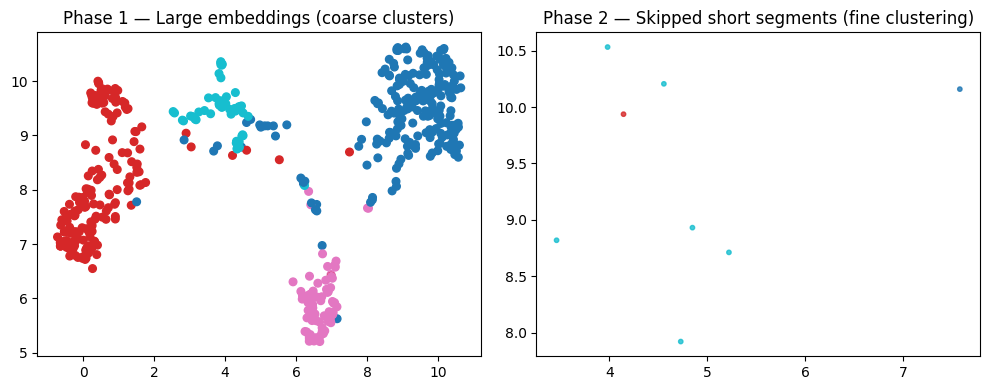

[NeMo W 2025-11-15 02:26:21 nemo_logging:361] C:\Users\Surface Studio\AppData\Local\Temp\ipykernel_15700\142535177.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
      cmap = plt.cm.get_cmap("Dark2", len(all_spks))
    


6796 10879 50895 147617
DER=0.4645 (Miss=0.0460, FA=0.0737, Conf=0.3448)


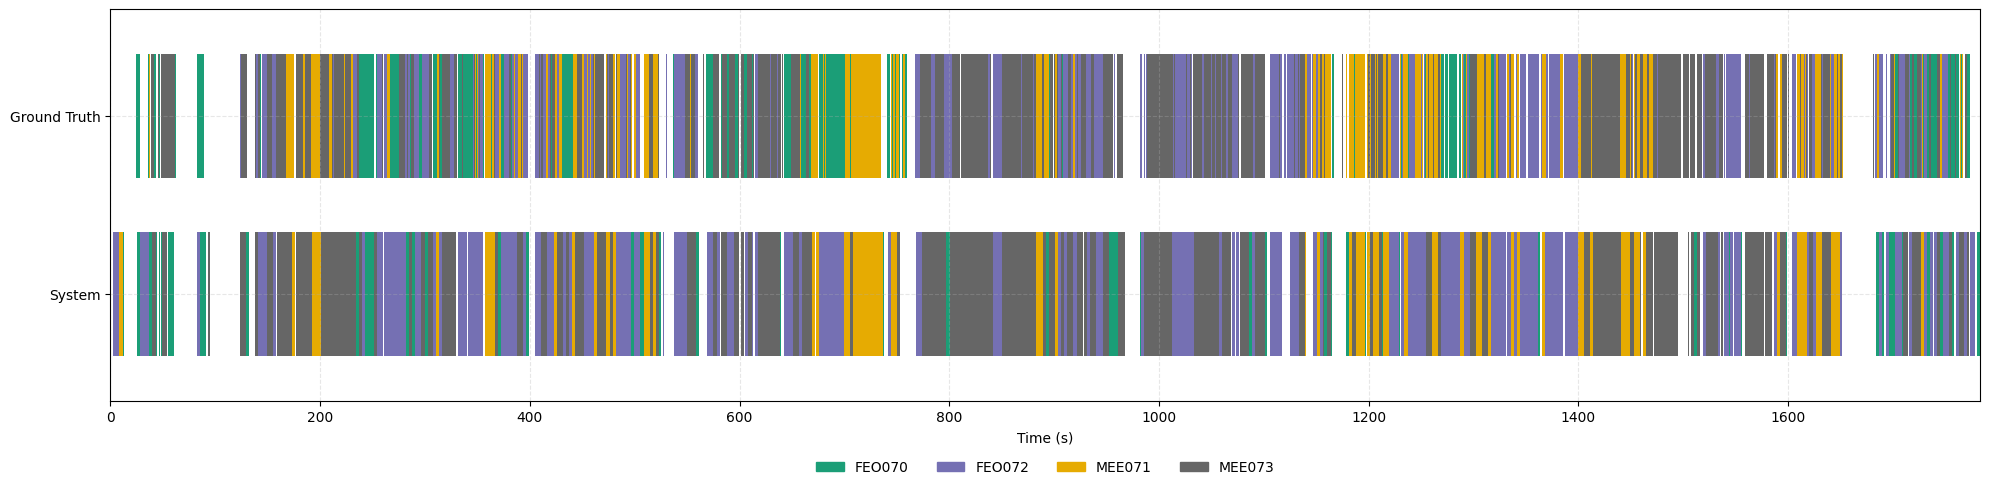

Quality=0.61 | MERGE:sys MEE071 covers {'MEE071', None, 'FEO072', 'MEE073', 'FEO070'} | MERGE:sys FEO070 covers {'MEE071', None, 'FEO072', 'MEE073', 'FEO070'} | MERGE:sys MEE073 covers {'MEE071', None, 'FEO072', 'MEE073', 'FEO070'} | MERGE:sys FEO072 covers {'MEE071', None, 'FEO072', 'MEE073', 'FEO070'} | SPLIT:gt FEO072 split across {'MEE071', 'FEO072', 'MEE073', 'FEO070'} | SPLIT:gt MEE073 split across {'MEE071', 'FEO072', 'MEE073', 'FEO070'} | SPLIT:gt MEE071 split across {'MEE071', 'FEO072', 'MEE073', 'FEO070'} | SPLIT:gt FEO070 split across {'MEE071', 'FEO072', 'MEE073', 'FEO070'}


Transcribing: 100%|██████████| 42/42 [08:05<00:00, 11.57s/it]


[{'start': '00:00:02', 'end': '00:00:37', 'speaker': 'Speaker 1', 'text': " You  didn't  need  a  laptop  today.  No,  I  didn't  actually.  I  still  got  three  microphones  off.  Actually,  if  you  could  move  your  microphone  a  bit  closer  to  your  chin,  and  you  could  move  just  a  bit  down,  so  it's  not  right  in  front  of  your  mouth,  that's  good,  okay,  looks  good."}, {'start': '00:00:37', 'end': '00:00:40', 'speaker': 'Speaker 3', 'text': ' Okay,  okay,  okay,  no  one'}, {'start': '00:00:40', 'end': '00:00:43', 'speaker': 'Speaker 0', 'text': " in?  I'll  take  notes  this  time,  I'll  take  notes  this"}, {'start': '00:00:43', 'end': '00:00:49', 'speaker': 'Speaker 3', 'text': ' time.  I  wish'}, {'start': '00:00:49', 'end': '00:00:55', 'speaker': 'Speaker 0', 'text': ' I  could  get  this  first  thing  and  just  sort  of  did  a  really  sort  of  breathe,  not'}, {'start': '00:00:55', 'end': '00:00:58', 'speaker': 'Speaker 3', 'text': ' like  a,  you

In [32]:
avg_miss = avg_fa = avg_conf = 0
idx = 0
for idx, row in enumerate(ds):
    # audio_path = row["audio"]["path"]   # local path in HF cache
    # full_path = os.path.join(base_dir, audio_path)
    # if idx in [0, 1]:
    #     continue
    audio_bytes = row["audio"]["bytes"]
    waveform, sample_rate = torchaudio.load(io.BytesIO(audio_bytes))
    # resample if needed
    if sample_rate != 16000:
        waveform = torchaudio.functional.resample(waveform, sample_rate, 16000)
        sample_rate = 16000
    waveform = ensure_mono(waveform)
    num_samples = waveform.shape[-1]
    duration_sec = num_samples / sample_rate

    hours = int(duration_sec // 3600)
    minutes = int((duration_sec % 3600) // 60)
    seconds = int(duration_sec % 60)

    print(f"Audio duration: {hours:02d}:{minutes:02d}:{seconds:02d}")
    
    # speech_segments, labeled_segments, speaker_labels = diarization(waveform, sample_rate, vad_model, speaker_encoder, row)
    diar_map = diarization(waveform, sample_rate, vad_model, speaker_encoder, wavlm_model, row, use_cosine_norm=False, plot=True)
    speech_segments = diar_map["merged_segments"]
    speaker_labels = diar_map["labels"]
    # der_benchmark(speech_segments, sample_rate, speaker_labels, row)
    der, miss_rate, fa_rate, conf_rate = der_benchmark_full(speech_segments, sample_rate, speaker_labels, row)
    diag, summary = label_diagnostics(speech_segments, sample_rate, speaker_labels, row)
    # print(diag)
    print(summary)
    avg_miss += miss_rate
    avg_fa += fa_rate
    avg_conf += conf_rate

    chunks = chunk_by_silence_and_overlap(speech_segments, sample_rate, max_chunk=60, overlap=2)
    # print(chunks)
    transcript = transcribe_chunks(waveform, sample_rate, chunks, asr_model)
    final_result = assign_speakers(transcript, speech_segments, sample_rate)
    diar_speech = process_timestamps(final_result, sample_rate)
    print(diar_speech)
    raw_speech_diarization: str = postprocess_diarization(client, diar_speech)
    final_speech_diarization = concat_json_arrays(raw_speech_diarization)
    save_transcriptions_json(final_speech_diarization, f"transcriptions/final_transcriptions{idx}.json")
    # break  # demo with first sample
    # if idx > 4:
    break
data_size = idx + 1
print(avg_miss / data_size, avg_fa /data_size, avg_conf/data_size)

13089 8272 56555 147708
DER=0.5275 (Miss=0.0886, FA=0.0560, Conf=0.3829)
Quality=0.53 
0.08861402226013486 0.05600238308013107 0.38288379776315434

11904 7087 63885 147708
DER=0.5611 (Miss=0.0806, FA=0.0480, Conf=0.4325)
Quality=0.49
0.08059143715980177 0.047979797979797977 0.43250873344707125

In [ ]:
0.15035275887779345+0.0550184621859962+0.21968930646020884

In [ ]:
0.09648998247952342+0.08058672501130586+0.2482858411048024

In [ ]:
0.09716092726322172+0.09315076278174769+0.18292676870146515

In [ ]:
# diag["frame_errors"]
for err in diag["frame_errors"]:
    if err["gt"] != err["sys"]:
        if err["end_time"] - err["start_time"] >= 0.5:
            print(f'{(err["end_time"] - err["start_time"]):.02f}s ', end=",")

In [ ]:
raw_speech_diarization: str = postprocess_diarization(client, diar_speech)
final_speech_diarization = concat_json_arrays(raw_speech_diarization)

In [8]:
diar_speech_test = [
    {'start': '00:00:02', 'end': '00:00:37', 'speaker': 'Speaker 1', 'text': " You  didn't  need  a  laptop  today.  No,  I  didn't  actually.  I  still  got  three  microphones  off.  Actually,  if  you  could  move  your  microphone  a  bit  closer  to  your  chin,  and  you  could  move  just  a  bit  down,  so  it's  not  right  in  front  of  your  mouth,  that's  good,  okay,  looks  good."}, 
    {'start': '00:00:37', 'end': '00:00:40', 'speaker': 'Speaker 3', 'text': ' Okay,  okay,  okay,  no  one'}, {'start': '00:00:40', 'end': '00:00:43', 'speaker': 'Speaker 0', 'text': " in?  I'll  take  notes  this  time,  I'll  take  notes  this"}, 
    {'start': '00:00:43', 'end': '00:00:49', 'speaker': 'Speaker 3', 'text': ' time.  I  wish'}, 
    {'start': '00:00:49', 'end': '00:00:55', 'speaker': 'Speaker 0', 'text': ' I  could  get  this  first  thing  and  just  sort  of  did  a  really  sort  of  breathe,  not'}, {'start': '00:00:55', 'end': '00:00:58', 'speaker': 'Speaker 3', 'text': ' like  a,  you  know,  version  of  what  we  have  to  do.'}, 
    {'start': '00:01:22', 'end': '00:01:23', 'speaker': 'Speaker 1', 'text': ' Interesting  stuff  at  the  meeting?'}, {'start': '00:01:33', 'end': '00:02:20', 'speaker': 'Speaker 0', 'text': " Ja.  Actually  for  that  I  was  just  copying  them  one  straight  over  the  other  document  so  it's  all  whatever.  Okay,  yeah,  I  see  that's  fine.  You  see"}, 
    {'start': '00:02:20', 'end': '00:02:29', 'speaker': 'Speaker 1', 'text': " it?  Oh,  sure,  sure,  sure.  I'm  not  sure  if  we  need  the  outline  as  a  prototype.  I  mean,  what  are  we"}, 
    {'start': '00:02:29', 'end': '00:02:35', 'speaker': 'Speaker 0', 'text': " going  to  put  into  that?  Well,  just  sort  of,  well,  the  thing  is,  yeah,  we're  going  to  be  touching  on  all  that  during  the  other  part  of  the  process.  Yeah,  because  I  mean,"}, 
    {'start': '00:02:35', 'end': '00:02:38', 'speaker': 'Speaker 1', 'text': " that's  better  than  what  we're  doing  here,  isn't  it,  the  whole..."}, 
    {'start': '00:02:38', 'end': '00:02:53', 'speaker': 'Speaker 0', 'text': " Yeah,  well,  it's  just  something  that  he  had  mentioned  in  the  previous,  like  just  to  sort  of  have  a  prototype  together  and  just  saying  that  we  could  potentially  do  that.  Yeah,  we  can  start  something.  This  could  be  just  a,  I  think,  just  describe"}, 
    {'start': '00:02:53', 'end': '00:02:55', 'speaker': 'Speaker 2', 'text': " some  screenshots,  isn't  it?"}, 
    {'start': '00:02:57', 'end': '00:03:12', 'speaker': 'Speaker 0', 'text': " Yeah,  sure.  Like  the  thing  is,  I  was  thinking  even  the  stuff  that  I  was  doing,  I  mean,  just  throw  the  screenshots  in  there  when  you  talk  about  what  you're  doing.  Yeah,  you're  kidding  me.  Can  we  just  ignore  that?  Oh,  yeah,  well,  actually,  yeah,  I  had  that  at  the  very  end,  screenshots,  put  that  screenshot  on  the  screenshot.  I  didn't  know  that.  Yeah,  you  hear"}, 
    {'start': '00:03:12', 'end': '00:03:19', 'speaker': 'Speaker 2', 'text': " that,  yeah,  it's  a  screenshot  there  and  stuff.  You  hear  that  screenshots  by  the  thing,  each  one  or...  thing,  each  one,  or  have  just  a  bunch  of  them  in  one  section."}, 
    {'start': '00:03:21', 'end': '00:03:52', 'speaker': 'Speaker 0', 'text': " Anyways,  so  yeah,  this  is  just  very  general  structure.  I  guess  from  this,  we  can  just  pop  in  our  little  blurbs.  Yeah,  I've  written  this  up  with  segmentation.  All  right,  cool.  Nice.  So  I  know  if  there's  other  stuff  that  you  think  should  be  done  to  this,  I  could  do  that  before  I'm  able  to,  you  guys.  Otherwise,  if  it's  someone  else  want  to  work  together.  Actually,  I  can  probably  still  throw  it  together  if  you  want.  Put  your  parts  into  this  one.  I  think  that  it  should  do.  Perfection  is  fine."}, 
    {'start': '00:03:56', 'end': '00:03:56', 'speaker': 'Speaker 3', 'text': " That's  a  good"}, 
    {'start': '00:03:56', 'end': '00:03:59', 'speaker': 'Speaker 0', 'text': " idea.  Let's  just  cut  out  the  middle  man.  Yeah,  exactly."}, {'start': '00:03:59', 'end': '00:04:01', 'speaker': 'Speaker 1', 'text': " You're  not  going  to  get  attention  going  around  anyways."}, 
    {'start': '00:04:04', 'end': '00:04:08', 'speaker': 'Speaker 3', 'text': " And  I'm  going  to  be  like,  you  know,  maybe  speak  a  little  English."}, 
    {'start': '00:04:13', 'end': '00:04:14', 'speaker': 'Speaker 0', 'text': ' Yeah,  well,'}, 
    {'start': '00:04:14', 'end': '00:04:15', 'speaker': 'Speaker 1', 'text': " I  mean,  it's  up  to  you."}, 
    {'start': '00:04:13', 'end': '00:04:14', 'speaker': 'Speaker 0', 'text': ' Felly,'}, 
    {'start': '00:04:14', 'end': '00:04:42', 'speaker': 'Speaker 1', 'text': " er  es  i  chi  oedd  ym  mwyn  fyddwch.  Felly  hollwch  i  bobl,  gwyliaeth  eu  lle  ddim  i  gweld  i  ni.  A  hynny,  rwy 'n  gobeithio  ti  arno.  Rydyn  ni 'n  ymweld  i  chi  ei  gweld  i  chi,  wrth  bod  yr  hyn  o  weld,  ac  neu  oeddoddi 'n  y  pethau  a 'r  rheло  i  들.  Rydyn  ni 'n  bwysig  nw!  Rydyn  ni 'n  bwysig  nw,  rydyn  ni 'n  bwysig  yn  ddweud  hyd  yn  euddi,  felly  mae 'n"}, 
    {'start': '00:04:42', 'end': '00:04:44', 'speaker': 'Speaker 3', 'text': ' deall  siarad!  Yna  nifer  trwyd.'}, 
    {'start': '00:04:46', 'end': '00:04:47', 'speaker': 'Speaker 0', 'text': " Rhaid  i  chi 'n  meddwl  yw  unig."}, 
    {'start': '00:04:49', 'end': '00:04:50', 'speaker': 'Speaker 3', 'text': " Roedd  e 'n  meddwl.  Efallai  os  oed"}, 
    {'start': '00:04:50', 'end': '00:04:55', 'speaker': 'Speaker 1', 'text': " yn  fan.  Felly  mae  nifer  ond  i  rhan  o 'r  newid."}, 
    {'start': '00:04:57', 'end': '00:05:05', 'speaker': 'Speaker 0', 'text': " Rwy 'n  erbyn  o 'r  drwng  i  ychydig.  So...  OK.  So  I'll  turn  it  off  for  you."}, 
    {'start': '00:05:07', 'end': '00:05:10', 'speaker': 'Speaker 1', 'text': " Yeah,  do  what  you  want  to  do  with  first  and  then  I'll..."}, 
    {'start': '00:05:10', 'end': '00:05:12', 'speaker': 'Speaker 2', 'text': " I'll  look.  I'll  tell  you.  No,  I'm  not  telling  you  that."}, 
    {'start': '00:05:13', 'end': '00:05:15', 'speaker': 'Speaker 1', 'text': " And  I'll  send  it  out  to  you  again."}, 
    {'start': '00:05:16', 'end': '00:05:29', 'speaker': 'Speaker 0', 'text': " Was  there  anything  else  we  wanted  to  add  to  the  timeline?  I  mean,  essentially,  was  what,  like,  you  can't  see  it,  right?  Oh,  there's  more.  Well,  that's  the  original.  Oh,  this  is  the  one  that,  okay.  Yeah,  yeah,  it's  just  copied  straight  out."}, 
    {'start': '00:05:30', 'end': '00:05:55', 'speaker': 'Speaker 1', 'text': " Probably  want  to  think  about  if  we  want  to  change  our  goals  and  stuff.  I  think  one  thing  that  we  could  probably  skip  totally  is  the  removing  things  from  the  body  of  fire.  That's  what  I  thought  as  well.  I  mean,  are  we  actually  gonna  attempt  that?  No,  I  don't  think  so  either.  Yeah,  I  think  it's  gonna  be,  we  don't  even  know  how  to  approach  that  now."}, 
    {'start': '00:05:57', 'end': '00:06:05', 'speaker': 'Speaker 2', 'text': " It's  a  good  thing  to  have  to  say  what  we  could  have  done  if  we  had  more  time.  That's  a  good  future  work  thing,  isn't  it?  Yeah.  It's  a  fun  report.  Should  have  we  had  more  time?"}, 
    {'start': '00:06:06', 'end': '00:06:09', 'speaker': 'Speaker 0', 'text': " Yeah,  yeah,  yeah.  That's  fine.  Unless  we  just"}, 
    {'start': '00:06:09', 'end': '00:06:10', 'speaker': 'Speaker 3', 'text': ' cover  some  sort  of  time  warp  things.'}, 
    {'start': '00:06:14', 'end': '00:06:27', 'speaker': 'Speaker 1', 'text': ' So  maybe,  I  mean,  we  should  definitely,  well,  we  could  probably  not  put  it  under  this  heading  but  put  it  under  changes  since  the  initial  specification  and  say,  we  decided  the  timing'}, 
    {'start': '00:06:27', 'end': '00:06:31', 'speaker': 'Speaker 0', 'text': ' was  too  short.  We  thought  there  were  more  important  things  to  do  at  our  time.'}, 
    {'start': '00:06:33', 'end': '00:06:50', 'speaker': 'Speaker 1', 'text': ' We  prefer  to  concentrate  on  the  main.  And  I  think  we  should  probably  comment  explicitly  on  the  milestones  here  as  well  and  say,  we  managed  to  do,'}, 
    {'start': '00:06:51', 'end': '00:06:56', 'speaker': 'Speaker 0', 'text': " yeah,  this  one  is,  or  some  of  them  were  a  bit  later  or  something.  Yeah,  that's  a  good  one.  We  could  have  shown"}, 
    {'start': '00:06:56', 'end': '00:07:02', 'speaker': 'Speaker 1', 'text': ' a  section.  Like,  we  have  a  prototype  GUI,  you  know.  Yeah,  we  managed  to  do  that.  Nicely.'}, 
    {'start': '00:07:03', 'end': '00:07:05', 'speaker': 'Speaker 2', 'text': ' Best  for  on  target  or'}, 
    {'start': '00:07:05', 'end': '00:07:11', 'speaker': 'Speaker 0', 'text': " something.  Yeah,  yeah.  That's  more  or  less.  Yeah,  but  that's  not  good.  That's  very,  well.  Plus  or  minus  three  days.  It"}, 
    {'start': '00:07:11', 'end': '00:07:14', 'speaker': 'Speaker 1', 'text': " doesn't  have  to  know  exactly.  Yeah,  that's  a  good"}, 
    {'start': '00:07:14', 'end': '00:07:17', 'speaker': 'Speaker 0', 'text': ' one.  I  mean,  yeah,'}, 
    {'start': '00:07:17', 'end': '00:07:19', 'speaker': 'Speaker 1', 'text': " I  mean,  it's  not  finished,"}, 
    {'start': '00:07:19', 'end': '00:07:23', 'speaker': 'Speaker 2', 'text': " but...  So  I've  only  got  six  days  to  do  the  topic  segment."}, 
    {'start': '00:07:23', 'end': '00:07:31', 'speaker': 'Speaker 0', 'text': " Jesus.  I  don't  know.  You  don't  know  who  the  SPNL  PSI  must  be.  And"}, 
    {'start': '00:07:31', 'end': '00:07:40', 'speaker': 'Speaker 1', 'text': " you  can  say,  yeah,  we're  still  aiming  for  the...  development  to  be  completely  unmarked  or  something.  Speaking  character,"}, 
    {'start': '00:07:40', 'end': '00:07:43', 'speaker': 'Speaker 2', 'text': ' is  this  supposed  to  be  done  already?  Oh,  really?  Yeah,  two  days'}, 
    {'start': '00:07:43', 'end': '00:07:44', 'speaker': 'Speaker 0', 'text': ' ago.'}, 
    {'start': '00:07:42', 'end': '00:07:43', 'speaker': 'Speaker 2', 'text': ' Yeah,  two  days'}, 
    {'start': '00:07:43', 'end': '00:07:50', 'speaker': 'Speaker 0', 'text': ' ago.  For  one  of  those,  something  that  you  want  to  change  and  delete  from  a  list  of  expectations?'}, 
    {'start': '00:07:52', 'end': '00:07:55', 'speaker': 'Speaker 2', 'text': " Give  me  a  week  and  I'll  tell  you  the  answer.  Should"}, 
    {'start': '00:07:55', 'end': '00:07:58', 'speaker': 'Speaker 0', 'text': ' we  put  a  hint  that  something  like  that  might  happen  into  the  document?'}, 
    {'start': '00:07:59', 'end': '00:08:01', 'speaker': 'Speaker 2', 'text': ' Maybe  the  speaker  characterization  might  get  slimmer.'}, 
    {'start': '00:08:01', 'end': '00:08:16', 'speaker': 'Speaker 1', 'text': " Yeah,  that's  right.  I  really  want  to  do  it.  It's  not  going  to  be  difficult  if  at  least  have  all  the  information  pop  up  that  is  already  in  the  metadata  file.  That's  going  to  be  new  work  to  do.  So  it's  definitely  going  to  be  something  natural.  We  might  make  it  disappear,  but  we"}, 
    {'start': '00:08:16', 'end': '00:08:19', 'speaker': 'Speaker 3', 'text': ' might  thin  it  down  a  bit.  But'}, 
    {'start': '00:08:19', 'end': '00:08:24', 'speaker': 'Speaker 1', 'text': " we  might  not.  Yeah,  we  might  turn  out  what  you  didn't  think."}, 
    {'start': '00:08:28', 'end': '00:08:34', 'speaker': 'Speaker 2', 'text': ' The  atomic  segmentation  with  LC  second  textiles  basically  done  in  just  case  to  be'}, 
    {'start': '00:08:34', 'end': '00:08:37', 'speaker': 'Speaker 0', 'text': ' done.  Tuned?  Yeah,  tuned.  We  did  a'}, 
    {'start': '00:08:37', 'end': '00:08:39', 'speaker': 'Speaker 2', 'text': " search  of  the  parameters,  but  it's  made  in."}, 
    {'start': '00:08:40', 'end': '00:08:41', 'speaker': 'Speaker 0', 'text': " Let's  see  what  happens.  Well,  it's"}, 
    {'start': '00:08:47', 'end': '00:09:08', 'speaker': 'Speaker 1', 'text': " That  was  good.  We  should  probably,  sorry,  we  should  probably  do  another  responsibility  of  packages  as  well.  That's  what  he  hinted  that  we  should  also  indicate  who  is  responsible  for  what."}, 
    {'start': '00:09:09', 'end': '00:09:18', 'speaker': 'Speaker 0', 'text': " Like,  probably  just  copy  that  straight  away  along  as  well.  That's  essentially  the  same  as  it  was.  More  detail,  specifically.  What  you  could  put,"}, 
    {'start': '00:09:18', 'end': '00:09:18', 'speaker': 'Speaker 3', 'text': ' you  know.'}, 
    {'start': '00:09:29', 'end': '00:09:35', 'speaker': 'Speaker 1', 'text': " I  don't  know,  I  don't  think,  but  are  things  that  we  have  together,  should  we?  I"}, 
    {'start': '00:09:35', 'end': '00:09:38', 'speaker': 'Speaker 0', 'text': " mean,  now?  Yeah,  I  think  so.  Yeah,  I'm  glad  you"}, 
    {'start': '00:09:38', 'end': '00:09:41', 'speaker': 'Speaker 1', 'text': ' brought  it  and  you  have  the  other.  But  what  about  the...'}, 
    {'start': '00:09:42', 'end': '00:09:48', 'speaker': 'Speaker 0', 'text': " ...discluencies?  What,  we're  skipping  the  audio  one,  and  then  it's  not  easy.  Yeah,  we"}, 
    {'start': '00:09:48', 'end': '00:09:54', 'speaker': 'Speaker 1', 'text': ' just  keep  it  together  on  the  paper.  Have  you  taken  any  more  of  it?  Have  you  taken'}, 
    {'start': '00:09:54', 'end': '00:10:04', 'speaker': 'Speaker 0', 'text': " any  more  of  the  look  at  it?  No,  not  the  discluencies.  Okay,  we  could  probably...  I  don't  have  a  lot  of  time  to  look  at  that  before  tomorrow.  Yeah,"}, 
    {'start': '00:10:05', 'end': '00:10:07', 'speaker': 'Speaker 1', 'text': " maybe.  We  could  just  make  it  up.  Like  I'll  claim"}, 
    {'start': '00:10:07', 'end': '00:10:11', 'speaker': 'Speaker 0', 'text': ' one,  you  claim  the  other  for  the  search  things,  and  then  we  could  leave  that  one  as  a  joint  one.'}, 
    {'start': '00:10:12', 'end': '00:10:17', 'speaker': 'Speaker 1', 'text': ' Yeah.  It  might  be  good.  Have  you  managed  any  further  on  the  search  thing?'}, 
    {'start': '00:10:18', 'end': '00:10:38', 'speaker': 'Speaker 0', 'text': " I  found,  finally  today,  something  that  I  can  build  it  in,  and  I  should  have  something  for  tomorrow.  I  should  at  least  have  a  GUI  on  that  one.  I  don't  want  to  get  something,  I  want  to  see  this,  I  want  to  get  it  together,  have  an  image  of  my  mom,  just  want  to  see  it  on  the  thing  and  then  give  her  a  screenshot."}, 
    {'start': '00:10:42', 'end': '00:10:50', 'speaker': 'Speaker 1', 'text': " Yeah,  my  intent  is  to  work  on  these  things  tomorrow  a  bit  more  as  well,  so  I  don't  know  if  we'll  send  it  in  the  afternoon  or  if  I  can  add  a  few  sentences"}, 
    {'start': '00:10:50', 'end': '00:10:57', 'speaker': 'Speaker 0', 'text': " to  what  I've  done.  It  doesn't  really  matter.  I  mean,  if  you  write  the  sentences  first  as  well,  I  mean,  with  the  intention"}, 
    {'start': '00:10:57', 'end': '00:10:59', 'speaker': 'Speaker 1', 'text': ' that  this  is  done.  And  also,'}, 
    {'start': '00:10:59', 'end': '00:11:08', 'speaker': 'Speaker 0', 'text': " sometimes  it's  a  bit  of  a  motivating  factor,  too.  I  mean,  you  write  down  the  words  and  the  ideas  as,  oh,  okay,  we'll  do  this.  How  about  the"}, 
    {'start': '00:11:08', 'end': '00:11:16', 'speaker': 'Speaker 2', 'text': ' underlying  data  for  the  converted  file?  Well,  I'}, 
    {'start': '00:11:16', 'end': '00:11:39', 'speaker': 'Speaker 1', 'text': " still,  like,  struggle  with  Java  stuff.  I  think  I  was  wondering  about  that.  I  haven't  looked  at  it  so  much,  but  if  any  of  you  guys  know  how  we  could  do  that,  like,  from  the  extract  words  that  you  did,  like,  also,  in  extract  timesfams"}, 
    {'start': '00:11:39', 'end': '00:11:45', 'speaker': 'Speaker 2', 'text': " or  something,  is  it?  Ychydig  i 'w  meddwl.  Fe  mawais  eich  sefydl."}, 
    {'start': '00:11:47', 'end': '00:11:48', 'speaker': 'Speaker 0', 'text': ' Efallai'}, 
    {'start': '00:11:48', 'end': '00:12:15', 'speaker': 'Speaker 2', 'text': " y  bydd  anod  i 'r  nhw,  roi  chi 'n  gwahanol.  Fe  mae 'n  meddwl  yn  llwyddo  français  ynglyn  o 'r  nodi 'r  llwyddo.  Nid  o 'r  ffarsad  o 'r  hyfforddiadau.  Reit  i 'r  hyfforddiadau  ynglyn  iddo.  Ac  mae  hi 'n  femwys  i  22 -24  oes  arniiau.  i  fydd  gennych  y  pagdreif.  Roi  arniwch  â  ddwy  i 'r  meddwl  a  fe  ddwy  i 'r  bobl  efallai  ym  ysgolol.  Caelwch  I  a  Unol.  Mae  yna 'r  unrhywbid  sy 'n  gwybod,  a  mae 'n  gael  fel  starwydeg  umhiff  yma  os  Fygen.  Felly  mae 'n  wneud  debyg."}, 
    {'start': '00:12:30', 'end': '00:12:33', 'speaker': 'Speaker 0', 'text': " ddweud?  Mae  hefyd  o  gynnwys  ym  ymuno  8  o 'ch  ymchwil  cwель."}, 
    {'start': '00:12:47', 'end': '00:12:53', 'speaker': 'Speaker 1', 'text': ' So,  did  you  made  another  end  browser?  Is  there  something  that  I  should?  There  is,  but'}, 
    {'start': '00:12:53', 'end': '00:13:17', 'speaker': 'Speaker 0', 'text': " I  haven't  made  a  lot  of  changes  to  it,  so  I  might  just  delete  what  I've  done  and  copied  it  from  yours,  because  I'm  sure  you've  probably  made  some  changes  already.  Not  since  you  don't  do  it.  Oh,  really?  Since  Friday?  No.  Okay.  But  I  would  tonight,  I  see.  Okay,  all  right,  I  see.  Okay,  I  thought  you  said  that  you  had  written  some  things  that  maybe  I've  caught  some  bugs  and  that  you  were  coming  pixels  on  the  weekend  or  something.  No.  Okay.  After  the  weekend."}, 
    {'start': '00:13:18', 'end': '00:13:19', 'speaker': 'Speaker 3', 'text': ' Okay.  The  weekend  was  after.'}, 
    {'start': '00:13:22', 'end': '00:14:01', 'speaker': 'Speaker 0', 'text': " Yes,  if  you  know.  Although  there's  stuff  out  there  that,  actually,  I'm  gonna  try  and  minimize  the  amount  of  changes  that  I  made  to  end  browser  anyways.  Shouldn't,  shouldn't  be  an  issue.  Actually,  just  to  clarify,  last  week  when  we  were  talking  about  our  search  results,  like  if  we  have  topics  as  well  as  transcripts  as  well  as  in  the  summaries,  do  we  want  separate  result  panes  for  each  of  those  or  do  we  want  them  all  in  one  pane  with  like  an  icon  or  a  different  color?  one  pane  with  like  an  icon  or  a  different  color  or  something  to  indicate  what  type  of  result  they  are  so  that  when  they  click  on  that  it's  going  to  go  to  the  relevant  thing,  like  just  if  they  check  all  three  say  topics,  have  three  different  windows  come  up?  Or  three,"}, 
    {'start': '00:14:01', 'end': '00:14:08', 'speaker': 'Speaker 1', 'text': ' like  so.  At  the  moment  is  there  a  window  that  comes  up?  Or  is  that  a  second  result  of  pain?'}, 
    {'start': '00:14:12', 'end': '00:14:42', 'speaker': 'Speaker 0', 'text': " I  think  what  we  sort  of  discussed  last  week  was  to  have  it  on  the  same  window,  so  it'll  be  on  the  search  window,  bottom  half  of  the  search  window.  I  don't  know  if  we  still  want  to  keep  it  that  way,  but  that's  what  it's  going  to  be  working  with.  So  it's  just  like  you  click  those  and  it  just  loads  up,  splits  that  thing  into  two  or  three  or  whatever  it  is,  one,  two,  three,  depending  on  which  one  you  check.  So  if  you  want  to  do  it  that  way,  it  probably  doesn't  matter  too  much.  Just  try  and  think  if  there's  going  to  be  any  other  issues  down  the  road,  I  wouldn't  depend  on.  Well,  you"}, 
    {'start': '00:14:42', 'end': '00:14:49', 'speaker': 'Speaker 2', 'text': ' can  confuse  me.  Do  you  have  three  separate  windows  for  three  separate  different  types  of  results?  No,  just  Panes,'}, 
    {'start': '00:14:49', 'end': '00:15:00', 'speaker': 'Speaker 0', 'text': " result  Panes.  Okay,  not  three  different  ones.  No.  It's  when  we  click  topics  and  summaries  for  what  we  want  to  search,  there'll  be  two  result"}, 
    {'start': '00:15:00', 'end': '00:15:03', 'speaker': 'Speaker 2', 'text': " Panes.  So  for  topics.  I  don't  know"}, 
    {'start': '00:15:03', 'end': '00:15:06', 'speaker': 'Speaker 1', 'text': " really  tabs.  I  quite  like  the  idea  of  a  tab  in  there.  But  then  you  can't"}, 
    {'start': '00:15:06', 'end': '00:15:09', 'speaker': 'Speaker 0', 'text': " see  all  of  them  at  the  same  time.  But  you  wouldn't  want  to  compare"}, 
    {'start': '00:15:09', 'end': '00:15:12', 'speaker': 'Speaker 1', 'text': ' the  result,  the  one  topic  result  with  one  summary'}, 
    {'start': '00:15:12', 'end': '00:15:18', 'speaker': 'Speaker 0', 'text': " result.  No,  but  the  thing  is  if  you're  looking,  if  you  check  them  both,  you'll  see  all  the  results.  Especially"}, 
    {'start': '00:15:18', 'end': '00:15:21', 'speaker': 'Speaker 1', 'text': ' if  you  get  results  for  the  same  meeting.'}, 
    {'start': '00:15:21', 'end': '00:15:31', 'speaker': 'Speaker 0', 'text': " Yeah,  exactly.  So  there's  some  way  in  the  topic  and  the  transcript  is  true.  Or  we  could  just  put  them  all  into  one  result  pane  on  that  same"}, 
    {'start': '00:15:31', 'end': '00:15:34', 'speaker': 'Speaker 1', 'text': ' window.  I  mean,  we  could  order  them  by  meeting,  for'}, 
    {'start': '00:15:34', 'end': '00:15:40', 'speaker': 'Speaker 0', 'text': " example.  Oh  yeah,  I  guess  that's  the  other  thing,  whether  we  want  to  have  this  reorder  by...  Yeah,  well,"}, 
    {'start': '00:15:40', 'end': '00:15:46', 'speaker': 'Speaker 1', 'text': " I  mean,  that's  the  second  step,  the  first  question  is...  The  second  step,  the  first  question  is,  how  do  we  want  to  order  them  in  the  first"}, 
    {'start': '00:15:46', 'end': '00:15:52', 'speaker': 'Speaker 0', 'text': " place?  I  think  probably  by  medium,  it  makes  more  sense.  Essentially,  they're  in  time"}, 
    {'start': '00:15:52', 'end': '00:15:58', 'speaker': 'Speaker 3', 'text': ' order,  so  that  kind  of  makes  more  sense.  Yeah,  maybe  we  should  do  that.'}, 
    {'start': '00:16:01', 'end': '00:16:05', 'speaker': 'Speaker 0', 'text': " Yeah,  it  should  be  easy.  No,  I  don't  know,  it  should  be  fairly  easy."}, 
    {'start': '00:16:22', 'end': '00:16:23', 'speaker': 'Speaker 3', 'text': ' But  why'}, 
    {'start': '00:16:23', 'end': '00:16:25', 'speaker': 'Speaker 1', 'text': " don't  you  just  color  code"}, 
    {'start': '00:16:25', 'end': '00:16:51', 'speaker': 'Speaker 0', 'text': " those,  the  results  to...  Sometimes  in  a  case  like  that,  like  a  run  across  in  other  languages,  it's  hard  to  tell  what  kind  of  object  it  was  originally,  once  it's  put  into  like  a  list  box  or  something.  It's  hard  to  tell  whether  it  was  a  transcript  or  whatever,  and  then  if  we're  highlighting  something  in  a  transcript  window,  it  may  be  difficult  to  get  that  information  back  once  it's  just  in  a  list  box,  and  I  don't  know  this  box."}, 
    {'start': '00:16:53', 'end': '00:17:12', 'speaker': 'Speaker 1', 'text': " No,  but  if  you...  Where  is  it  that's  coming  from?  If  you  do  it  straight  from,  you  know,  you  get  the  result  and  then  there's  some  if  statement  saying  straight  on  the  rock  bottom  level  saying  if  you  found  a  segment,  then  color  it,  print  it,  and  you  read  it  or  what  about  it,  as  opposed  to...  Yeah,"}, 
    {'start': '00:17:13', 'end': '00:17:36', 'speaker': 'Speaker 0', 'text': " it's  just  like  from  past  experience.  There's  goofy  little  things  that  happen  and  it  just  doesn't  let  you  save  certain  things  and  it  just  kind  of...  certain  things  and  it's  just  kind  of  trying  to  do  a  different  kind  of  to  go  to  a  different  window.  So  if  you  want  to  go  to  the  actual  highlight  the  transcript  or  highlight  the  topic  at  that  point,  that's  sort  of  where  it  starts  getting  a  little  bit  tricky,  because  you're  working  with  an  event  handler  within  the  one  panel  or  a  list"}, 
    {'start': '00:17:36', 'end': '00:17:38', 'speaker': 'Speaker 1', 'text': ' box  or  whatever  it  is.'}, 
    {'start': '00:17:40', 'end': '00:17:44', 'speaker': 'Speaker 0', 'text': " There  are  ways  around  it,  but  whether  we'll  be  able  to  figure  something  out  like  action."}, 
    {'start': '00:17:49', 'end': '00:17:56', 'speaker': 'Speaker 1', 'text': " Yeah,  I  mean,  at  the  moment  it  works.  It  works  with  highlighting  in  the  transcript  window,  doesn't  it?"}, 
    {'start': '00:17:57', 'end': '00:18:06', 'speaker': 'Speaker 0', 'text': ' So  I  think  he  was  saying  that  as  long  as  we  implement  that  interface,  it  should  work  with  anything  that  we  do,  like'}, 
    {'start': '00:18:06', 'end': '00:18:08', 'speaker': 'Speaker 3', 'text': ' highlighting.  I  think  that  was,'}, 
    {'start': '00:18:08', 'end': '00:18:11', 'speaker': 'Speaker 1', 'text': ' who  was  saying  that?  What  do  you  mean  it  should  work  with  anything?'}, 
    {'start': '00:18:11', 'end': '00:18:20', 'speaker': 'Speaker 0', 'text': " I  think  it  was  just  like,  it's  a  long  as  we  implement  one  of  these  interfaces  for  this  particular  type  of  window,  we  should  be  able  to  have  that  highlighting.  I  have  that  highlighting,  okay?  Mm -hmm.  I  don't"}, 
    {'start': '00:18:20', 'end': '00:18:23', 'speaker': 'Speaker 3', 'text': " know.  I  don't  know.  I  think  that's  it."}, 
    {'start': '00:18:25', 'end': '00:18:53', 'speaker': 'Speaker 1', 'text': " Yn  hytr,  gallwn  y  cyffrwch  yn  y  de  declined  y  byddwch,  ac  nid  yw 'r  bobl  yn  cael  combi 'r  ystodol  yma,  ddyn  nhw 'n  gael  y  pethau.  ac  ar  y  cwmwg  continued  o  gynnes  hyflith  o  wnaeth  roedd  yn  ddylch  mewn  gwahanol .嫁  tîl  weld  sy 'n  cael  eu  bod  yn  egaraith  o  Pomfarkadol,  felly  mae"}, 
    {'start': '00:18:53', 'end': '00:18:55', 'speaker': 'Speaker 0', 'text': " nhw  ar  y  cwmwld  yn  ei  gweled  o 'r  sgwrdd,"}, 
    {'start': '00:19:08', 'end': '00:19:08', 'speaker': 'Speaker 1', 'text': '呢?'}, 
    {'start': '00:19:10', 'end': '00:19:13', 'speaker': 'Speaker 2', 'text': ' NOM  tex  hardships.  Most  of  these  are  called  NOM.  Yeah,'}, 
    {'start': '00:19:13', 'end': '00:19:16', 'speaker': 'Speaker 1', 'text': " that's  the  NOM  anyway.  Night  Object  Model,"}, 
    {'start': '00:19:16', 'end': '00:19:17', 'speaker': 'Speaker 0', 'text': ' I  think.'}, 
    {'start': '00:19:19', 'end': '00:19:20', 'speaker': 'Speaker 3', 'text': ' Night  Object  Model,'}, 
    {'start': '00:19:21', 'end': '00:19:21', 'speaker': 'Speaker 0', 'text': ' I  think.'}, 
    {'start': '00:19:38', 'end': '00:19:42', 'speaker': 'Speaker 3', 'text': ' With  the  removing'}, 
    {'start': '00:19:42', 'end': '00:19:44', 'speaker': 'Speaker 2', 'text': ' the  disciplines,  have  you  done  anything  with  that'}, 
    {'start': '00:19:44', 'end': '00:19:45', 'speaker': 'Speaker 0', 'text': " yet?  I  haven't."}, 
    {'start': '00:19:48', 'end': '00:20:01', 'speaker': 'Speaker 2', 'text': " Because  I  was  wondering  how  we're  going  to  write  it  back  to  HTML,  I  mean,  XML  if  we  did  the  processing,  writing  it  back  to  XML.  I  thought  we  were"}, 
    {'start': '00:20:01', 'end': '00:20:04', 'speaker': 'Speaker 0', 'text': ' just  going  to  have  that  as  words,  like  not  as'}, 
    {'start': '00:20:04', 'end': '00:20:10', 'speaker': 'Speaker 2', 'text': ' XML,  just  sort  of  as  a  blurb  of  text.  What  was  that?  Text  file.  Well,  transcript.  No,'}, 
    {'start': '00:20:10', 'end': '00:20:12', 'speaker': 'Speaker 0', 'text': ' because  then  we  need  all  the  other  data  if  we  want  to  keep  it  a  transcript.'}, 
    {'start': '00:20:13', 'end': '00:20:19', 'speaker': 'Speaker 2', 'text': " Well,  very  much  what  you  can  do  with  it  if  it's  not  in  XML.  There  is  some  bizarre  method"}, 
    {'start': '00:20:19', 'end': '00:20:34', 'speaker': 'Speaker 1', 'text': " that  puts  things  back  into  XML.  Why  do  we  want  it  in  XML  though?  I  mean,  I  thought  we'd  just  selectively  write  the  XML  that  we've  got.  So  as  opposed  to.  Oh,  select  what  we  want."}, 
    {'start': '00:20:34', 'end': '00:20:36', 'speaker': 'Speaker 2', 'text': ' Just  take  bits  of  the  XML.  Only  in  certain  segments.'}, 
    {'start': '00:20:37', 'end': '00:20:54', 'speaker': 'Speaker 1', 'text': " Yeah,  only  print  out.  Y  cysylltu  chaingof  ar  fion  cael  ei  teimlo 'r  cyffredinol  yn  dechrau  i  fynd,  ac  mae 'r  cyffredinol  yn  arblillio.  Rwy 'n  ei  weithio  ddyn  nhw 'n  falch  o 'r  cyffredinol  eich  mewn  cyffredinol.  Felly  o 'r  cyffredinol  i  weld  fod  genedd  y  gallwn.  Roedd,  mae 'n  dda  i 'n  ddysgfa  i 'r  effaith  ar  fy  nifer."}, 
    {'start': '00:20:56', 'end': '00:21:00', 'speaker': 'Speaker 0', 'text': " Roedd  gan  gwybod  chwarae  griff  mothersiaid.  Roedd  y  gallwn  ei  ddysgfa  i 'r  effaith  ar  hyn  o  ddysgfa  i 'r  effaith."}, 
    {'start': '00:21:00', 'end': '00:21:04', 'speaker': 'Speaker 2', 'text': " Rwy 'n  meddwl  bod  ein  cywch  yn  ei  ddydiogel  i  gael  arna  ymddangos."}, 
    {'start': '00:21:34', 'end': '00:21:36', 'speaker': 'Speaker 1', 'text': " Rwy 'n  digon  llwythiaeth  chi 'n  gwahanol...  You  know  that's  not  how  I  too,  but  we  don't  really  need  to  do  much  more  with  it."}, 
    {'start': '00:21:36', 'end': '00:21:42', 'speaker': 'Speaker 0', 'text': " That's  right.  I  think  it's  like,  well  how  would  we  display  that  like  if  we  do  take  disciplines  we  just  create  a  text  file  take  the  disciplines"}, 
    {'start': '00:21:42', 'end': '00:21:48', 'speaker': 'Speaker 2', 'text': " to  the  text  file.  It  would  just  be  like  a  summary  it  would  look  like  we  won't  say  speaker  X  says  this  speaker  Y  says"}, 
    {'start': '00:21:48', 'end': '00:21:54', 'speaker': 'Speaker 0', 'text': ' that  speaker  Z  says  this.  Unless  we  extract  that  over  the  file  when  we  create  the  text  file.  Yeah.  Then  it  will  look  ugly  probably  because'}, 
    {'start': '00:21:54', 'end': '00:21:57', 'speaker': 'Speaker 2', 'text': " it  would  look  just  black  and  white.  Unless  you  want  to  start  typing.  It's  probably"}, 
    {'start': '00:21:57', 'end': '00:22:15', 'speaker': 'Speaker 1', 'text': " the  best  thing  to  do  as  you  said.  I  don't  think  it's  going  to  take  long  to  produce  anyway.  I  think  it's  actually—  I  mean,  these  meetings  are  not  endlessly  long,  it's  just  words  and  to  print  all  of  them  out  selectively.  It  doesn't  on  the  fly  anyway,  doesn't  it?  Yeah.  So  then"}, 
    {'start': '00:22:15', 'end': '00:22:18', 'speaker': 'Speaker 2', 'text': ' it  just  goes  through  and  says  that  this  word  he  calls  that  can  print.'}, 
    {'start': '00:22:19', 'end': '00:22:19', 'speaker': 'Speaker 1', 'text': ' Yeah.  Yeah.'}, 
    {'start': '00:22:21', 'end': '00:22:24', 'speaker': 'Speaker 2', 'text': ' Just  a  bunch  of  this  stuff.  You'}, 
    {'start': '00:22:24', 'end': '00:22:42', 'speaker': 'Speaker 1', 'text': " can  nearly  do  it  together  with  the  transcription,  with  the  original  transcription,  having  one  in  parallel.  So  if  certain,  you  know,  if  it's  a...  ac  yn  fwy  i 'r  un  oherwydd,  math  yw 'r  hyn  o  afasiad,  ac  yn  fwy  i 'r  un  oherwydd  mae 'n  fwy  o 'r  hyn  o 'r  un  oherwydd  ond...  ma  chi 'n  fyddodol  am  ddweud"}, 
    {'start': '00:22:42', 'end': '00:22:44', 'speaker': 'Speaker 3', 'text': ' ac'}, 
    {'start': '00:22:44', 'end': '00:22:48', 'speaker': 'Speaker 2', 'text': " yn  llin  o 'r  mwrdd.  Mae 'n  ddi  wrth  gwrs  hefyd  tu,  mae 'n  dwylo  dweud  ac  yn  ddweud  ond  mae 'n  hwn  o  radd  i 'w"}, 
    {'start': '00:22:48', 'end': '00:23:17', 'speaker': 'Speaker 1', 'text': " ddechrau 'n  dechrau.  Mae 'n  ddweud.  Felly  mae 'n  amlwg  am  ydyrgrifyd  yng  nghymru  yw  os  iddo 'i  fyrdad  i 'r  un  oherwydd.  Felly  mae  hwn  oedd  yn  meddwl  i 'r  arhopio 'r  ffordd.  ddweud  hyn  o 'r  rhaid  oherwydd  maen  nhw.  Mae  rhai,  roedd  yna  yma  yng  Nghymru  yma,  rwy 'n  yn  gwneud  i  fod  yna  am  gweithio  i  dinne,  i  fod  yn  gweithio  i  ddweud  i  gyd  yn  gweithio  i  honno  efo  rhai.  Order  o!"}, 
    {'start': '00:23:24', 'end': '00:23:25', 'speaker': 'Speaker 2', 'text': ' Mae'}, 
    {'start': '00:23:25', 'end': '00:23:31', 'speaker': 'Speaker 0', 'text': ' adreumio  ymddindol  ta  yn  llunio  gyd  yna  o  bobl  yn  eu'}, 
    {'start': '00:23:31', 'end': '00:23:32', 'speaker': 'Speaker 2', 'text': " ddefnyddio  efo 'i  amddindol.  Rwy 'n  defnyddio  y  peth  trefio  â  mi  yn  maen  nhw 'r  mwy,  yng  Nghymru."}, 
    {'start': '00:23:30', 'end': '00:23:31', 'speaker': 'Speaker 0', 'text': ' flip'}, 
    {'start': '00:23:31', 'end': '00:23:34', 'speaker': 'Speaker 2', 'text': ' it  into  just  the  transform  zone'}, 
    {'start': '00:23:34', 'end': '00:24:01', 'speaker': 'Speaker 0', 'text': " like  this  style  sheet.  It's  kind  of  like  there's  usually  things  built  in  to,  well  it  should  be  built  into  Java  and  process  XML.  It  just  creates  whatever  file  it's  going  to  be.  It's  been  a  couple  of  years  since  I've  looked  at  things  like  this,  but  that  might  even  be  an  easier  way.  And  then  that  way  we  could  even  preprocess  that  before.  I  don't  know,  we  don't  want  to  have  to  do  that,  right?  I  wouldn't  even"}, 
    {'start': '00:24:01', 'end': '00:24:09', 'speaker': 'Speaker 2', 'text': ' try  to  read  it  in  XML,  Java  was  complicated  enough.  I  gave  up  doing  that  completely.  I  devoted  back  to  night  stuff'}, 
    {'start': '00:24:09', 'end': '00:24:11', 'speaker': 'Speaker 0', 'text': ' because  it  was  not  too  much  or  much  easy.'}, 
    {'start': '00:24:12', 'end': '00:24:18', 'speaker': 'Speaker 2', 'text': ' So  if  we  can  do  it  with  night  stuff,  do  it  with  night  stuff.  Java  and  trying  to  do  it  was  just  so  complicated,'}, 
    {'start': '00:24:18', 'end': '00:24:19', 'speaker': 'Speaker 0', 'text': ' it  was  really  cute.'}, 
    {'start': '00:24:21', 'end': '00:24:25', 'speaker': 'Speaker 2', 'text': " You  can't  believe  it.  You  have  to  start  defining  object  models  like"}, 
    {'start': '00:24:25', 'end': '00:25:09', 'speaker': 'Speaker 0', 'text': " the  night  thing  and  getting  used  to  this.  We'll  be  there  soon.  I  was  thinking  I  might  try  and  talk  to  Jonathan  and  Gene,  just  to  see  what  system  they  used  to  develop  this  stuff.  It  would  be  nice  to  have  all  the  tools  there  and  just  have  the  object  model  and  just  kind  of  like  plug  and  play  with  everything  and  just  actually  use  the  system  at  a  higher  level  rather  than  kind  of  playing  around  with  a  little  bit  of  coding  and  modifying  your  coding  and  just  sort  of  see  what  they're  doing.  It  seems  to  be  more  interesting  to  use  it  as"}, 
    {'start': '00:25:09', 'end': '00:25:13', 'speaker': 'Speaker 3', 'text': ' a  real  developer  mode.  It'}, 
    {'start': '00:25:13', 'end': '00:25:15', 'speaker': 'Speaker 0', 'text': ' just  seems  like  a  little  tinkering  here  and  there,  just  adding  a  couple  things.'}, 
    {'start': '00:25:19', 'end': '00:25:22', 'speaker': 'Speaker 1', 'text': " What  programming  is  all  about,  I'm  afraid?  No,  it"}, 
    {'start': '00:25:22', 'end': '00:25:33', 'speaker': 'Speaker 0', 'text': " shouldn't  be.  It  should  be  higher  level,  it  should  be  conceptual,  and  coming  up  with  brilliant  ideas,  and  then  just  bringing  those  to  reality.  Yeah,  maybe."}, 
    {'start': '00:25:33', 'end': '00:25:43', 'speaker': 'Speaker 1', 'text': " It  was  the  higher  people.  Well,  I  mean,  yeah,  why  don't  you  put  both  of  those  ideas  into  that"}, 
    {'start': '00:25:43', 'end': '00:25:44', 'speaker': 'Speaker 3', 'text': ' paragraph'}, 
    {'start': '00:25:44', 'end': '00:25:55', 'speaker': 'Speaker 1', 'text': " and  say  you'll  have  a  look  at  both  of  something  if  you  want  to  do  it?  I  personally  don't  want  to  mess  with  writing  files  or  anything  at  the  moment,  I  want  to  do  it  superficially."}, 
    {'start': '00:25:58', 'end': '00:25:58', 'speaker': 'Speaker 3', 'text': ' Like'}, 
    {'start': '00:25:58', 'end': '00:26:20', 'speaker': 'Speaker 0', 'text': " the  thing  that  I  was  thinking  there  as  well  is  that  once  it's  done  for  you  know  one  meeting  it's  done  Just  it  doesn't  make  any  difference  really  out  of  the  way  to  me.  It's  like  if  it's  fast  enough  on  the  fly  That's  what  the  only  issue  I  have  with  on  the  fly  Yeah,  especially  with  Java"}, 
    {'start': '00:26:28', 'end': '00:26:29', 'speaker': 'Speaker 1', 'text': ' Yeah,'}, 
    {'start': '00:26:29', 'end': '00:26:30', 'speaker': 'Speaker 2', 'text': " it's  after  it's  like"}, 
    {'start': '00:26:32', 'end': '00:26:33', 'speaker': 'Speaker 0', 'text': " It's  just  it's  just  a  fall  it  really"}, 
    {'start': '00:26:43', 'end': '00:26:47', 'speaker': 'Speaker 1', 'text': " Bwn  tych  yn  fawr 'n  dda  i  chi  ddim  yn  ymrydio  yn  y  fflusiwr  Ja"}, 
    {'start': '00:26:47', 'end': '00:26:58', 'speaker': 'Speaker 2', 'text': " yn  fryd  o 'r  fflusiwr  i  wneud 'r  solio,  ond  yn  fy  modd  arall  y  hoffad  yn  ym  OS  A  i  weldgo  yn  ddarparu  o  jou  i 'r  hoffad  Wel  mae 'n  cael  ei  flaen,  mae"}, 
    {'start': '00:26:58', 'end': '00:26:59', 'speaker': 'Speaker 1', 'text': "'n  cael  ei  ddod..."}, 
    {'start': '00:27:00', 'end': '00:27:02', 'speaker': 'Speaker 0', 'text': ' pan  ein  fyddo  yn  gweithio  arall  hefyd'}, 
    {'start': '00:27:04', 'end': '00:27:06', 'speaker': 'Speaker 1', 'text': " Felly  mae 'r  fflusio  yn  ei"}, 
    {'start': '00:27:06', 'end': '00:27:13', 'speaker': 'Speaker 2', 'text': " fflusio  o 'r  rhan"}, 
    {'start': '00:27:13', 'end': '00:27:20', 'speaker': 'Speaker 0', 'text': " addysg  Mae 'n  fudio,  ond  i  rhoi 'r  mod  i 'r  unig  oedd  yn  cyffredig.  Oni 'r  manifestian  yn  ei  ffyrdd  yni.  Y  maes  iawn,"}, 
    {'start': '00:27:20', 'end': '00:27:29', 'speaker': 'Speaker 2', 'text': " mae 'n  gwneud  gwahanol.  Because  if  you  have  a  discursive  thing  here  and  then  another  discursive  thing  there,  if  they're  not  together  you  lose  a  lot  of  it."}, 
    {'start': '00:28:03', 'end': '00:28:06', 'speaker': 'Speaker 3', 'text': ' That  sounds  good.  Anything  else  you'}, 
    {'start': '00:28:06', 'end': '00:28:16', 'speaker': 'Speaker 1', 'text': " want  to  talk  about?  We  all  have  sleep,  aren't  we?  Burnt  out.  Burnt  out."}, 
    {'start': '00:28:19', 'end': '00:28:20', 'speaker': 'Speaker 3', 'text': ' Maybe  a  sleep.'}, 
    {'start': '00:28:25', 'end': '00:28:27', 'speaker': 'Speaker 1', 'text': " So  we're  all  still  writing  our"}, 
    {'start': '00:28:27', 'end': '00:28:30', 'speaker': 'Speaker 3', 'text': ' summary,'}, 
    {'start': '00:28:30', 'end': '00:28:35', 'speaker': 'Speaker 0', 'text': " sending  them  to  you.  Or  she'll  just  take,  she  can  take  it  from  now  on."}, 
    {'start': '00:28:35', 'end': '00:28:38', 'speaker': 'Speaker 1', 'text': ' How  come?  I'}, 
    {'start': '00:28:38', 'end': '00:28:46', 'speaker': 'Speaker 0', 'text': " can,  I'm  not  sure  if  you  want  to  send  them  to  me.  Actually  that's  a  good  idea.  I'll  take  one  quick  look  over,  try  and  get  it  as  good  as  I  think  that  way."}, 
    {'start': '00:28:47', 'end': '00:28:49', 'speaker': 'Speaker 2', 'text': " You  stick  it  together,  she'll  shine  it."}, 
    {'start': '00:28:50', 'end': '00:29:00', 'speaker': 'Speaker 1', 'text': ' And  then  send  it  on  to  us  so  that  we  can  nod.  And  correct  back  any  things  that  I  thought  was  wrong.'}, 
    {'start': '00:29:01', 'end': '00:29:04', 'speaker': 'Speaker 0', 'text': ' They  were  taking  dialogue  back.'}, 
    {'start': '00:29:05', 'end': '00:29:06', 'speaker': 'Speaker 3', 'text': ' I  love  you.'}, 
    {'start': '00:29:08', 'end': '00:29:11', 'speaker': 'Speaker 1', 'text': " Okay.  Sounds  good.  I  haven't  used  my  pen."}, 
    {'start': '00:29:14', 'end': '00:29:16', 'speaker': 'Speaker 0', 'text': " I've  read  it  on,  like,"}, 
    {'start': '00:29:16', 'end': '00:29:18', 'speaker': 'Speaker 3', 'text': ' four  lines.  Okay.'}, 
    {'start': '00:29:19', 'end': '00:29:22', 'speaker': 'Speaker 1', 'text': ' Um,  yeah.  12 .30.  Tomorrow.'}, 
    {'start': '00:29:23', 'end': '00:29:27', 'speaker': 'Speaker 0', 'text': ' Oh.  Good'}, 
    {'start': '00:29:27', 'end': '00:29:28', 'speaker': 'Speaker 1', 'text': ' job  you  reminded  me.'}, 
    {'start': '00:29:32', 'end': '00:29:32', 'speaker': 'Speaker 3', 'text': ' Yeah.'}, 
    {'start': '00:29:33', 'end': '00:29:37', 'speaker': 'Speaker 1', 'text': ' Yeah.  What  do  you  know?  I  was  going  to  have  a  line.'}, 
    {'start': '00:29:39', 'end': '00:29:43', 'speaker': 'Speaker 3', 'text': " That's  good.  12 .30.  12 .30"}, 
    {'start': '00:29:43', 'end': '00:29:44', 'speaker': 'Speaker 2', 'text': " is  alright,  yeah.  That's  what  we're  talking  about."}
]


In [10]:
raw_speech_diarization: str = postprocess_diarization(client, diar_speech_test)
final_speech_diarization = concat_json_arrays(raw_speech_diarization)

Post-processing complete.
[
{'start': '00:00:02', 'end': '00:00:40', 'speaker': 'Speaker 1', 'text': "You didn't need a laptop today. No, I didn't actually. I still got three microphones off. Actually, if you could move your microphone a bit closer to your chin, and you could move just a bit down, so it's not right in front of your mouth, that's good, okay, looks good. Okay, okay, okay, no one"},
{'start': '00:00:40', 'end': '00:00:49', 'speaker': 'Speaker 0', 'text': "in? I'll take notes this time, I'll take notes this time. I wish"},
{'start': '00:00:49', 'end': '00:00:58', 'speaker': 'Speaker 0', 'text': 'I could get this first thing and just sort of did a really sort of breathe, not like a, you know, version of what we have to do.'},
{'start': '00:01:22', 'end': '00:01:23', 'speaker': 'Speaker 1', 'text': 'Interesting stuff at the meeting?'},
{'start': '00:01:33', 'end': '00:02:35', 'speaker': 'Speaker 0', 'text': "Ja. Actually for that I was just copying them one straight over the